# Wind Speed Validation: OBS vs ERA5 and OBS vs DANRA
### This notebook creates heatmaps for Correlation, RMSE, MBE, and Circular EMD with 10m height bins
### Only plots stations that have valid data
###  Uses 2D wind vectors (speed + direction) for circular EMD

In [1]:
import numpy as np
import pandas as pd
import xarray as xr
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
from scipy import stats
from scipy.stats import wasserstein_distance
from matplotlib.colors import LinearSegmentedColormap
import re
import warnings
warnings.filterwarnings('ignore')
from pyemd import emd
from pyemd import emd_with_flow
from scipy.interpolate import interp1d
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path
import matplotlib.patches as mpatches
from matplotlib.patches import Patch

# ============================================================================
# CONFIGURATION
# ============================================================================
OBS_FOLDER = Path("./OBS/data")
ERA5_FOLDER = Path("./ERA5/processed_version")
DANRA_FOLDER = Path("./DANRA/new")

# Height bin configuration (10m intervals from 5m to 255m)
BIN_EDGES = np.arange(5, 265, 10)
BIN_CENTRES = (BIN_EDGES[:-1] + BIN_EDGES[1:]) / 2

# Minimum data requirements
MIN_HOURS = 100

# Target years (set to None for all years, or specify like [2020])
TARGET_YEARS = 2022 #list(range(2001, 2024))

# Wind variable names
WIND_VARIABLE_NAMES = [
    'wind_speed', 'wind_speed_filtered', 'ws', 'wind', 'wspd',
    'wind_speed_10m', 'wind_speed_100m', 'sfc_wind', 'wind_spd',
    'WS10M', 'WS100M', 'WSPD', 'WIND_SPEED', 'wind_speed_mean',
    'wind_speed_avg', 'nl_wspd', 'F'
    ]

# Wind direction variable names (for OBS)
WIND_DIRECTION_NAMES = [
    'wind_direction', 'wd', 'dir', 'direction', 'wind_dir',
    'WD10M', 'WD100M', 'WDIR', 'wind_direction_mean', 'deg',
    'wdir', 'wdir10m', 'wdir100m', 'lev_wdir'
    ]   

# Time dimension names
TIME_DIMENSION_NAMES = [
    'time', 'Time', 'TIME', 't', 'T', 'datetime', 'Date', 'timestamp', 'valid_time'
    ]

# # Autocorrelation lag settings
ACF_LAG = 1  # Default lag-1 autocorrelation
ACF_MIN_DATA_POINTS = 100  # Minimum data points for ACF calculation

# print("Configuration loaded:")
# print(f"  Height bins: {len(BIN_CENTRES)} bins from {BIN_EDGES[0]} to {BIN_EDGES[-1]}m")
# print(f"  Target years: {TARGET_YEARS}")
# print(f"  Min hours required: {MIN_HOURS}")
# print(f"  ACF lag: {ACF_LAG}")'

In [2]:
obs_binned_cache = {}
era5_binned_cache = {}
danra_binned_cache = {}

In [3]:
# 2. Circular EMD Functions

def wind_to_cartesian(wind_speed, wind_direction_deg):
    """
    Convert wind speed and direction to Cartesian coordinates (u, v)
    
    Parameters:
    -----------
    wind_speed : array-like
        Wind speed in m/s
    wind_direction_deg : array-like
        Wind direction in degrees (meteorological convention: direction FROM which wind comes)
    
    Returns:
    --------
    u, v : tuple of arrays
        Eastward (u) and northward (v) wind components
    """
    wind_dir_rad = np.radians(wind_direction_deg)
    u = -wind_speed * np.sin(wind_dir_rad)
    v = -wind_speed * np.cos(wind_dir_rad)
    return u, v

def cartesian_to_wind_speed(u, v):
    """Convert Cartesian components to wind speed"""
    return np.sqrt(u**2 + v**2)

def cartesian_to_wind_direction(u, v):
    """Convert Cartesian components to wind direction (meteorological convention)"""
    wind_dir_rad = np.arctan2(-u, -v)
    wind_dir_deg = np.degrees(wind_dir_rad)
    wind_dir_deg = wind_dir_deg % 360
    return wind_dir_deg

def create_2d_histogram_uv(u_obs, v_obs, u_model, v_model, n_bins=25, range_uv=(-25, 25)):
    """
    Create 2D histograms for u and v components (Cartesian coordinates)
    """
    bin_edges_u = np.linspace(range_uv[0], range_uv[1], n_bins + 1)
    bin_edges_v = np.linspace(range_uv[0], range_uv[1], n_bins + 1)
    
    hist_obs, _, _ = np.histogram2d(u_obs, v_obs, bins=[bin_edges_u, bin_edges_v], density=True)
    hist_model, _, _ = np.histogram2d(u_model, v_model, bins=[bin_edges_u, bin_edges_v], density=True)
    
    hist_obs = hist_obs + 1e-10
    hist_model = hist_model + 1e-10
    
    hist_obs = hist_obs / hist_obs.sum()
    hist_model = hist_model / hist_model.sum()
    
    return hist_obs, hist_model, bin_edges_u, bin_edges_v

def create_distance_matrix_cartesian(n_bins, range_uv=(-25, 25)):
    """
    Calculate Euclidean distance matrix for Cartesian coordinates (u, v)
    """
    n_bins_total = n_bins * n_bins
    
    bin_edges = np.linspace(range_uv[0], range_uv[1], n_bins + 1)
    bin_centers = (bin_edges[:-1] + bin_edges[1:]) / 2
    
    u_centers, v_centers = np.meshgrid(bin_centers, bin_centers)
    u_centers_flat = u_centers.flatten()
    v_centers_flat = v_centers.flatten()
    
    distance_matrix = np.zeros((n_bins_total, n_bins_total))
    for i in range(n_bins_total):
        for j in range(n_bins_total):
            distance_matrix[i, j] = np.sqrt((u_centers_flat[i] - u_centers_flat[j])**2 + 
                                           (v_centers_flat[i] - v_centers_flat[j])**2)
    
    return distance_matrix, bin_centers, bin_centers



In [4]:
from ot import emd2

def calculate_circular_emd_wd(obs_wd, model_wd, n_sectors=12, wind_speed_weights=None, obs_ws=None):
    """
    Calculate Circular Earth Mover's Distance (CEMD) for wind direction distributions
    
    Parameters:
    -----------
    obs_wd : array-like
        Observed wind direction in degrees (meteorological convention)
    model_wd : array-like
        Model wind direction in degrees (meteorological convention)
    n_sectors : int
        Number of sectors to bin the wind directions (default: 12)
    wind_speed_weights : array-like, optional
        Wind speed weights for weighted histogram (default: None)
    obs_ws : array-like, optional
        Observed wind speed for weighting (required if wind_speed_weights is not None)
    
    Returns:
    --------
    cemd_value : float
        Circular Earth Mover's Distance in degrees
    """
    # Clean data
    valid_mask = ~(np.isnan(obs_wd) | np.isnan(model_wd))
    if wind_speed_weights is not None and obs_ws is not None:
        valid_mask &= ~np.isnan(obs_ws)
        obs_ws_clean = obs_ws[valid_mask]
    else:
        obs_ws_clean = None
    
    obs_wd_clean = obs_wd[valid_mask][np.isfinite(obs_wd[valid_mask])]
    model_wd_clean = model_wd[valid_mask][np.isfinite(model_wd[valid_mask])]
    
    if len(obs_wd_clean) < 10:
        return np.nan
    
    # Create bins
    bin_width = 360.0 / n_sectors
    bin_edges = np.array([i * bin_width for i in range(n_sectors + 1)])
    bin_centers = np.array([(i + 0.5) * bin_width for i in range(n_sectors)])
    
    # Create histograms
    if wind_speed_weights is not None and obs_ws_clean is not None:
        hist_obs, _ = np.histogram(obs_wd_clean, bins=bin_edges, 
                                   weights=obs_ws_clean, density=False)
        hist_model, _ = np.histogram(model_wd_clean, bins=bin_edges, 
                                     weights=obs_ws_clean, density=False)
    else:
        hist_obs, _ = np.histogram(obs_wd_clean, bins=bin_edges, density=False)
        hist_model, _ = np.histogram(model_wd_clean, bins=bin_edges, density=False)
    
    # Convert to float64 and add epsilon BEFORE normalization
    hist_obs = hist_obs.astype(np.float64) + 1e-10
    hist_model = hist_model.astype(np.float64) + 1e-10
    
    # Normalize to probability distributions
    hist_obs = hist_obs / np.sum(hist_obs)
    hist_model = hist_model / np.sum(hist_model)
    
    # Create circular distance matrix
    n_bins = len(bin_centers)
    distance_matrix = np.zeros((n_bins, n_bins), dtype=np.float64)
    for i in range(n_bins):
        for j in range(n_bins):
            diff = np.abs(bin_centers[i] - bin_centers[j])
            distance_matrix[i, j] = np.minimum(diff, 360.0 - diff)
    
    # Calculate EMD using emd2 (returns scalar directly)
    try:
        cemd_value = emd2(hist_obs, hist_model, distance_matrix)
        return float(cemd_value)
    except Exception as e:
        print(f"EMD calculation failed: {e}")
        return np.nan

In [5]:
def load_obs_data(file_path, target_years=None):
    """Load OBS wind speed and direction data with proper height matching"""
    try:
        ds = xr.open_dataset(file_path, decode_times=True)
        
        # Track if we're using _mc variables
        using_mc = False
        
        # Find wind speed variable - prioritize _mc versions
        wind_var = None
        for var_name in WIND_VARIABLE_NAMES:
            if f'{var_name}_mc' in ds.data_vars:
                wind_var = f'{var_name}_mc'
                using_mc = True
                print(f"    Using wind speed variable: {wind_var} (_mc version)")
                break
        
        if wind_var is None:
            for var_name in WIND_VARIABLE_NAMES:
                if var_name in ds.data_vars:
                    wind_var = var_name
                    print(f"    Using wind speed variable: {wind_var}")
                    break
        
        # Find wind direction variable
        wdir_var = None
        for var_name in WIND_DIRECTION_NAMES:
            if f'{var_name}_mc' in ds.data_vars:
                wdir_var = f'{var_name}_mc'
                print(f"    Using wind direction variable: {wdir_var} (_mc version)")
                break
        
        if wdir_var is None:
            for var_name in WIND_DIRECTION_NAMES:
                if var_name in ds.data_vars:
                    wdir_var = var_name
                    print(f"    Using wind direction variable: {wdir_var}")
                    break
        
        if wind_var is None:
            print(f"    WARNING: No wind speed variable found")
            ds.close()
            return {}, {}
        
        wind_data = ds[wind_var]
        wdir_data = ds[wdir_var] if wdir_var else None
        
        # Get time dimension and values
        time_dim = None
        for dim in TIME_DIMENSION_NAMES:
            if dim in ds.dims:
                time_dim = dim
                break
        
        if time_dim is None:
            for dim in TIME_DIMENSION_NAMES:
                if dim in ds.coords:
                    time_dim = dim
                    break
        
        if time_dim is None:
            print(f"    WARNING: No time dimension found")
            ds.close()
            return {}, {}
        
        # Extract time values
        if time_dim in ds.coords:
            time_values = pd.to_datetime(ds[time_dim].values)
        else:
            time_values = pd.to_datetime(ds[time_dim].values)
        
        # Normalize target years so scalar inputs work
        if target_years is not None:
            if isinstance(target_years, (int, np.integer)):
                target_years = [int(target_years)]
            elif isinstance(target_years, np.ndarray):
                target_years = target_years.tolist()
            elif isinstance(target_years, (list, tuple, set, pd.Index)):
                target_years = list(target_years)
            else:
                try:
                    target_years = list(target_years)
                except Exception:
                    target_years = [int(target_years)]

        # Get speed heights
        speed_heights = None
        speed_dim = None
        
        # Priority for speed height dimension
        for dim in ['lev_wspd_mc', 'lev_wspd', 'height', 'altitude']:
            if using_mc and dim == 'lev_wspd_mc' and dim in wind_data.dims:
                speed_heights = ds[dim].values if dim in ds.coords else wind_data[dim].values
                speed_dim = dim
                print(f"    Speed height dimension: {speed_dim} with {len(speed_heights)} levels")
                break
            elif dim in wind_data.dims:
                speed_heights = ds[dim].values if dim in ds.coords else wind_data[dim].values
                speed_dim = dim
                print(f"    Speed height dimension: {speed_dim} with {len(speed_heights)} levels")
                break
        
        if speed_heights is None:
            print(f"    WARNING: No speed height dimension found")
            ds.close()
            return {}, {}
        
        # Get direction heights separately
        dir_heights = None
        dir_dim = None
        
        if wdir_data is not None:
            for dim in ['lev_wdir_mc', 'lev_wdir', 'height', 'altitude']:
                if using_mc and dim == 'lev_wdir_mc' and dim in wdir_data.dims:
                    dir_heights = ds[dim].values if dim in ds.coords else wdir_data[dim].values
                    dir_dim = dim
                    print(f"    Direction height dimension: {dir_dim} with {len(dir_heights)} levels")
                    break
                elif dim in wdir_data.dims:
                    dir_heights = ds[dim].values if dim in ds.coords else wdir_data[dim].values
                    dir_dim = dim
                    print(f"    Direction height dimension: {dir_dim} with {len(dir_heights)} levels")
                    break
        
        # Create mapping between speed and direction heights
        height_mapping = {}
        if dir_heights is not None and len(dir_heights) > 0:
            print(f"    Creating height mapping...")
            for speed_h in speed_heights:
                nearest_idx = np.argmin(np.abs(dir_heights - speed_h))
                nearest_h = dir_heights[nearest_idx]
                height_mapping[float(speed_h)] = (int(nearest_idx), float(nearest_h))
                if len(speed_heights) <= 10:  # Print only if few levels
                    print(f"      Speed {speed_h:.1f}m → Direction {nearest_h:.1f}m (diff: {abs(speed_h - nearest_h):.1f}m)")
        
        # Load data using the mapping
        wind_speed_dict = {}
        wind_dir_dict = {}

        print(f"    Loading data for {len(speed_heights)} speed levels...")

        for i, speed_h in enumerate(speed_heights):
            try:
                # Extract wind speed at this height
                if speed_dim in wind_data.dims:
                    ws_data = wind_data.isel({speed_dim: i})
                else:
                    ws_data = wind_data

                # Extract along time dimension and convert to Series
                if time_dim in ws_data.dims:
                    ws_values = ws_data.squeeze().values
                    ws_values = np.atleast_1d(ws_values)
                    # Handle case where values might be 2D
                    if ws_values.ndim > 1:
                        ws_values = ws_values.flatten()
                    # Trim to match time values if needed
                    if len(ws_values) > len(time_values):
                        ws_values = ws_values[:len(time_values)]
                    elif len(ws_values) < len(time_values):
                        time_values = time_values[:len(ws_values)]

                    ws_series = pd.Series(ws_values, index=time_values, dtype=float)
                else:
                    ws_series = pd.Series([ws_data.values], index=[time_values[0]] if len(time_values) > 0 else [], dtype=float)

                # Drop NaN
                ws_series = ws_series.dropna()
                if len(ws_series) == 0:
                    continue

                # Resample to hourly
                ws_series = ws_series.resample('1h').mean()
                ws_series = ws_series.dropna()

                # Filter by years if specified
                if target_years and len(ws_series) > 0:
                    ws_series = ws_series[ws_series.index.year.isin(target_years)]

                if len(ws_series) == 0:
                    continue

                # Load direction at mapped height
                wd_series = None
                if wdir_data is not None and dir_heights is not None and float(speed_h) in height_mapping:
                    dir_idx, dir_h = height_mapping[float(speed_h)]

                    if dir_idx < len(dir_heights):
                        if dir_dim in wdir_data.dims:
                            wd_data_level = wdir_data.isel({dir_dim: dir_idx})
                        else:
                            wd_data_level = wdir_data

                        # Extract direction values
                        if time_dim in wd_data_level.dims:
                            wd_values = wd_data_level.squeeze().values
                            wd_values = np.atleast_1d(wd_values)
                            if wd_values.ndim > 1:
                                wd_values = wd_values.flatten()
                            if len(wd_values) > len(time_values):
                                wd_values = wd_values[:len(time_values)]
                            elif len(wd_values) < len(time_values):
                                time_values_dir = time_values[:len(wd_values)]
                            else:
                                time_values_dir = time_values

                            wd_series = pd.Series(wd_values, index=time_values_dir, dtype=float)
                        else:
                            wd_series = pd.Series([wd_data_level.values], index=[time_values[0]] if len(time_values) > 0 else [], dtype=float)

                        if wd_series is not None:
                            wd_series = wd_series.dropna()
                            if len(wd_series) > 0:
                                wd_series = wd_series.resample('1h').mean().dropna()
                                if target_years and len(wd_series) > 0:
                                    wd_series = wd_series[wd_series.index.year.isin(target_years)]

                # Align timestamps if we have direction data
                if wd_series is not None and len(wd_series) > 0:
                    common_idx = ws_series.index.intersection(wd_series.index)
                    if len(common_idx) > 0:
                        wind_speed_dict[float(speed_h)] = ws_series.loc[common_idx]
                        wind_dir_dict[float(speed_h)] = wd_series.loc[common_idx]
                        if i < 3:
                            dir_h = height_mapping[float(speed_h)][1]
                            print(f"      Height {speed_h:.1f}m: {len(common_idx)} hours (matched with dir at {dir_h:.1f}m)")
                    else:
                        wind_speed_dict[float(speed_h)] = ws_series
                        if i < 3:
                            print(f"      Height {speed_h:.1f}m: {len(ws_series)} hours (no matching direction timestamps)")
                else:
                    wind_speed_dict[float(speed_h)] = ws_series
                    if i < 3:
                        print(f"      Height {speed_h:.1f}m: {len(ws_series)} hours (no direction data)")

            except Exception as e:
                if i < 3:
                    print(f"      Warning: Failed to process height {speed_h}: {type(e).__name__}: {e}")
                continue

        ds.close()
        print(f"    Successfully loaded {len(wind_speed_dict)} height levels for wind speed")
        if wind_dir_dict:
            print(f"    Successfully loaded {len(wind_dir_dict)} height levels for wind direction")

        return wind_speed_dict, wind_dir_dict
    except Exception as e:
        print(f"    ERROR loading OBS file {file_path}: {type(e).__name__}: {e}")
        try:
            ds.close()
        except Exception:
            pass
        return {}, {}


def load_era5_data(file_path, target_years=None):
    """Load ERA5 CSV with U/D columns for wind speed and direction levels"""
    try:
        df = pd.read_csv(file_path, parse_dates=['time'], index_col='time')
    except Exception as e:
        print(f"    ERROR loading ERA5 file {file_path}: {type(e).__name__}: {e}")
        return {}, {}

    if df.empty:
        return {}, {}

    if target_years is not None:
        if isinstance(target_years, (int, np.integer)):
            target_years = [int(target_years)]
        elif isinstance(target_years, np.ndarray):
            target_years = target_years.tolist()
        elif isinstance(target_years, (list, tuple, set, pd.Index)):
            target_years = list(target_years)
        else:
            try:
                target_years = list(target_years)
            except Exception:
                target_years = [int(target_years)]

    speed_columns = {}
    dir_columns = {}
    for col in df.columns:
        if isinstance(col, str):
            m = re.match(r'^[uU](\d+)$', col)
            if m:
                speed_columns[float(m.group(1))] = col
            m = re.match(r'^[dD](\d+)$', col)
            if m:
                dir_columns[float(m.group(1))] = col

    wind_speed_dict = {}
    wind_dir_dict = {}

    for height, speed_col in speed_columns.items():
        if speed_col not in df.columns:
            continue

        ws = pd.to_numeric(df[speed_col], errors='coerce')
        ws = ws.dropna().resample('1h').mean().dropna()
        if target_years is not None and len(ws) > 0:
            ws = ws[ws.index.year.isin(target_years)]
        if len(ws) == 0:
            continue

        wind_speed_dict[height] = ws

        dir_col = dir_columns.get(height)
        if dir_col and dir_col in df.columns:
            wd = pd.to_numeric(df[dir_col], errors='coerce')
            wd = wd.dropna().resample('1h').mean().dropna()
            if target_years is not None and len(wd) > 0:
                wd = wd[wd.index.year.isin(target_years)]
            if len(wd) > 0:
                common_idx = ws.index.intersection(wd.index)
                if len(common_idx) > 0:
                    wind_speed_dict[height] = ws.loc[common_idx]
                    wind_dir_dict[height] = wd.loc[common_idx]
                else:
                    wind_dir_dict[height] = wd

    return wind_speed_dict, wind_dir_dict


In [6]:
def load_danra_data(file_path, target_years=None):
    """Load DANRA wind components (u, v) from NetCDF file with all altitude levels"""
    try:
        ds = xr.open_dataset(file_path, decode_times=False)

        if target_years is not None:
            if isinstance(target_years, (int, np.integer)):
                target_years = [int(target_years)]
            elif isinstance(target_years, np.ndarray):
                target_years = target_years.tolist()
            elif isinstance(target_years, (list, tuple, set, pd.Index)):
                target_years = list(target_years)
            else:
                try:
                    target_years = list(target_years)
                except Exception:
                    target_years = [int(target_years)]

        def parse_time(var):
            values = var.values
            units = var.attrs.get('units', '')
            if isinstance(units, str):
                match = re.search(r'(?P<unit>\w+) since (?P<ref>.+)', units)
                if match:
                    unit = match.group('unit').lower()
                    ref = match.group('ref').split('+')[0].split('Z')[0].strip()
                    ref_time = pd.to_datetime(ref)
                    if unit in ('hours', 'hour', 'h'):
                        return ref_time + pd.to_timedelta(values.astype('float64'), unit='h')
                    if unit in ('minutes', 'minute', 'm'):
                        return ref_time + pd.to_timedelta(values.astype('float64'), unit='m')
                    if unit in ('seconds', 'second', 's'):
                        return ref_time + pd.to_timedelta(values.astype('float64'), unit='s')
                    if unit in ('days', 'day', 'd'):
                        return ref_time + pd.to_timedelta(values.astype('float64'), unit='D')
            return pd.to_datetime(values, utc=True)

        if 'valid_time' in ds.coords:
            time_index = pd.DatetimeIndex(parse_time(ds['valid_time']))
        elif 'valid_time' in ds.variables:
            time_index = pd.DatetimeIndex(parse_time(ds['valid_time']))
        elif 'time' in ds.coords:
            time_index = pd.DatetimeIndex(parse_time(ds['time']))
        elif 'time' in ds.variables:
            time_index = pd.DatetimeIndex(parse_time(ds['time']))
        elif 'analysis_time' in ds.variables:
            time_index = pd.DatetimeIndex(parse_time(ds['analysis_time']))
        else:
            ds.close()
            return {}, {}, {}, {}

        if 'u' not in ds.variables or 'v' not in ds.variables:
            ds.close()
            return {}, {}, {}, {}

        if 'altitude' not in ds.coords:
            ds.close()
            return {}, {}, {}, {}

        altitudes = ds.altitude.values
        wind_speed_dict = {}
        wind_dir_dict = {}
        u_dict = {}
        v_dict = {}

        for i, alt in enumerate(altitudes):
            try:
                u_component = ds['u'].isel(altitude=i)
                v_component = ds['v'].isel(altitude=i)

                u_series = pd.Series(u_component.values, index=time_index)
                v_series = pd.Series(v_component.values, index=time_index)

                u_series = u_series.dropna().resample('1h').mean().dropna()
                v_series = v_series.dropna().resample('1h').mean().dropna()

                if target_years is not None and len(u_series) > 0:
                    u_series = u_series[u_series.index.year.isin(target_years)]
                    v_series = v_series[v_series.index.year.isin(target_years)]

                if len(u_series) > 0 and len(v_series) > 0:
                    ws_series = pd.Series(cartesian_to_wind_speed(u_series.values, v_series.values), index=u_series.index)
                    wd_series = pd.Series(cartesian_to_wind_direction(u_series.values, v_series.values), index=u_series.index)

                    wind_speed_dict[float(alt)] = ws_series
                    wind_dir_dict[float(alt)] = wd_series
                    u_dict[float(alt)] = u_series
                    v_dict[float(alt)] = v_series
            except Exception:
                continue

        ds.close()
        return wind_speed_dict, wind_dir_dict, u_dict, v_dict
    except Exception:
        return {}, {}, {}, {}


In [7]:
# 4. Helper Functions

def normalize_station_name(name):
    """Normalize station name for matching"""
    name_lower = name.lower()
    
    # Define mapping of station names
    name_mapping = {
        'fino1': 'FINO1',
        'fino2': 'FINO2', 
        'fino3': 'FINO3',
        'cabauw': 'Cabauw',
        'hovsore': 'Hovsore', 
        'oesterild': 'Oesterild',
        'hamburg': 'Hamburg',
        'balticsea_lot3': 'Balticsea_lot3' ,
        'balticsea_lot4': 'Balticsea_lot4' ,
        'northsea_lot1': 'Northsea_lot1' ,
        'northsea_lot2': 'Northsea_lot2' ,
        'N-03-07-UW_V2': 'Windcube_N-03-07-UW_V2',
        'WEA_XR_1500m_VAD': 'WEA_XR_1500m_VAD', 
        'UW_XR_1600m_VAD': 'UW_XR_1600m_VAD', 
        'UW_XR_3000m_VAD': 'UW_XR_3000m_VAD'
        }
    
    # Try to find and return the standardized station name
    for station in name_mapping.keys():
        if station in name_lower:
            return name_mapping[station]
    
    # If no station found, clean up common patterns
    # Remove common suffixes and year patterns
    name_lower = re.sub(r'_[^_]*$', '', name_lower)  # Remove last underscore segment
    name_lower = re.sub(r'[-_]?\d{4}([-_]?\d{4})?$', '', name_lower)  # Remove year patterns
    name_lower = re.sub(r'\.(nc|csv)$', '', name_lower)  # Remove file extensions
    
    return name_lower

def get_station_stem(filepath):
    """Extract base station name from filename"""
    return normalize_station_name(Path(filepath).stem)

def find_matching_files(obs_files, model_files):
    """Match OBS files with model files"""
    matches = {}
    
    model_dict = {}
    for model_path in model_files:
        stem = get_station_stem(model_path)
        if stem not in model_dict:
            model_dict[stem] = []
        model_dict[stem].append(model_path)
    
    for obs_path in obs_files:
        obs_stem = get_station_stem(obs_path)
        
        if obs_stem in model_dict:
            matches[obs_path] = model_dict[obs_stem][0]
        else:
            for model_stem, model_paths in model_dict.items():
                if obs_stem in model_stem or model_stem in obs_stem:
                    matches[obs_path] = model_paths[0]
                    break
    
    return matches

def bin_by_height(data_dict):
    """Bin height levels into 10m intervals"""
    binned = {}
    heights = np.array(list(data_dict.keys()))
    
    for i, centre in enumerate(BIN_CENTRES):
        mask = (heights >= BIN_EDGES[i]) & (heights < BIN_EDGES[i+1])
        
        if mask.any():
            series_list = [data_dict[h] for h in heights[mask]]
            
            if len(series_list) == 1:
                combined = series_list[0]
            else:
                df = pd.concat(series_list, axis=1)
                combined = df.mean(axis=1).dropna()
            
            if len(combined) > 0:
                binned[centre] = combined
    
    return binned

def match_timestamps_with_direction(obs_speed_dict, obs_dir_dict, 
                                  model_speed_dict, model_dir_dict,
                                  model_u_dict=None, model_v_dict=None,
                                  use_log_profile=False, z0=0.1):
    """
    Match observations with model data using interpolation to observation heights.
    Now properly handles time indices and alignment.
    """
    if not obs_speed_dict or not model_speed_dict:
        return {}
    
    # Get observation heights
    obs_heights = sorted(obs_speed_dict.keys())
    model_heights = sorted(model_speed_dict.keys())
    
    # IMPORTANT: Convert all data to pandas Series with proper indices
    # This is the key fix - we need to preserve time information
    
    # First, convert model data to DataFrames with time indices
    model_speed_df = {}
    model_dir_df = {}
    model_u_df = {}
    model_v_df = {}
    
    for h in model_heights:
        if h in model_speed_dict:
            # Assuming model_speed_dict[h] is a pandas Series or array with time index
            if isinstance(model_speed_dict[h], pd.Series):
                model_speed_df[h] = model_speed_dict[h].copy()
            else:
                # If it's a numpy array, create a default index
                model_speed_df[h] = pd.Series(model_speed_dict[h])
        
        if model_dir_dict and h in model_dir_dict:
            if isinstance(model_dir_dict[h], pd.Series):
                model_dir_df[h] = model_dir_dict[h].copy()
            else:
                model_dir_df[h] = pd.Series(model_dir_dict[h])
        
        if model_u_dict and h in model_u_dict:
            if isinstance(model_u_dict[h], pd.Series):
                model_u_df[h] = model_u_dict[h].copy()
            else:
                model_u_df[h] = pd.Series(model_u_dict[h])
        
        if model_v_dict and h in model_v_dict:
            if isinstance(model_v_dict[h], pd.Series):
                model_v_df[h] = model_v_dict[h].copy()
            else:
                model_v_df[h] = pd.Series(model_v_dict[h])
    
    # Convert observation data to DataFrames with time indices
    obs_speed_df = {}
    obs_dir_df = {}
    
    for h in obs_heights:
        if h in obs_speed_dict:
            if isinstance(obs_speed_dict[h], pd.Series):
                obs_speed_df[h] = obs_speed_dict[h].copy()
            else:
                obs_speed_df[h] = pd.Series(obs_speed_dict[h])
        
        if obs_dir_dict and h in obs_dir_dict:
            if isinstance(obs_dir_dict[h], pd.Series):
                obs_dir_df[h] = obs_dir_dict[h].copy()
            else:
                obs_dir_df[h] = pd.Series(obs_dir_dict[h])
    
    # Find common time indices across all data
    all_indices = []
    
    # Collect indices from observation data
    for h in obs_heights:
        if h in obs_speed_df:
            all_indices.append(obs_speed_df[h].index)
    
    # Collect indices from model data
    for h in model_heights:
        if h in model_speed_df:
            all_indices.append(model_speed_df[h].index)
    
    if not all_indices:
        return {}
    
    # Find common time indices across ALL data
    common_index = all_indices[0]
    for idx in all_indices[1:]:
        common_index = common_index.intersection(idx)
    
    # Also ensure we have common indices for direction data
    dir_indices = []
    for h in obs_heights:
        if h in obs_dir_df:
            dir_indices.append(obs_dir_df[h].index)
    for h in model_heights:
        if h in model_dir_df:
            dir_indices.append(model_dir_df[h].index)
    
    if dir_indices:
        common_dir_index = dir_indices[0]
        for idx in dir_indices[1:]:
            common_dir_index = common_dir_index.intersection(idx)
        # Intersect with main common index
        common_index = common_index.intersection(common_dir_index)
    
    print(f"    Common time indices: {len(common_index)}")
    
    if len(common_index) < MIN_HOURS:
        print(f"    WARNING: Insufficient common timesteps: {len(common_index)}")
        return {}
    
    # Now align all data to the common index
    matched = {}
    
    # Prepare model data matrices aligned to common index
    model_speed_matrix = []
    model_dir_matrix = []
    model_u_matrix = []
    model_v_matrix = []
    
    for h in model_heights:
        if h in model_speed_df:
            # Align to common index
            aligned_speed = model_speed_df[h].reindex(common_index)
            model_speed_matrix.append(aligned_speed.values)
        
        if h in model_dir_df:
            aligned_dir = model_dir_df[h].reindex(common_index)
            model_dir_matrix.append(aligned_dir.values)
        
        if h in model_u_df:
            aligned_u = model_u_df[h].reindex(common_index)
            model_u_matrix.append(aligned_u.values)
        
        if h in model_v_df:
            aligned_v = model_v_df[h].reindex(common_index)
            model_v_matrix.append(aligned_v.values)
    
    # Convert to numpy arrays (n_heights x n_timesteps)
    model_speed_matrix = np.array(model_speed_matrix)
    model_dir_matrix = np.array(model_dir_matrix) if model_dir_matrix else None
    model_u_matrix = np.array(model_u_matrix) if model_u_matrix else None
    model_v_matrix = np.array(model_v_matrix) if model_v_matrix else None
    
    # Now process each observation height
    for obs_h in obs_heights:
        # Get observation data aligned to common index
        if obs_h not in obs_speed_df:
            continue
            
        obs_speed_aligned = obs_speed_df[obs_h].reindex(common_index)
        obs_speed_array = obs_speed_aligned.values
        
        if obs_h in obs_dir_df:
            obs_dir_aligned = obs_dir_df[obs_h].reindex(common_index)
            obs_dir_array = obs_dir_aligned.values
        else:
            obs_dir_array = None
        
        # Skip if no valid data
        if len(obs_speed_array) == 0 or np.all(np.isnan(obs_speed_array)):
            continue
        
        # Interpolate model data to observation height
        if use_log_profile:
            # Use log profile interpolation with multiple heights
            model_speed_interp = interpolate_log_profile_to_height(
                model_speed_matrix, model_heights, obs_h, z0
            )
            if model_dir_matrix is not None:
                model_dir_interp = interpolate_log_profile_to_height(
                    model_dir_matrix, model_heights, obs_h, z0
                )
            else:
                model_dir_interp = None
                
            if model_u_matrix is not None:
                model_u_interp = interpolate_log_profile_to_height(
                    model_u_matrix, model_heights, obs_h, z0
                )
            else:
                model_u_interp = None
                
            if model_v_matrix is not None:
                model_v_interp = interpolate_log_profile_to_height(
                    model_v_matrix, model_heights, obs_h, z0
                )
            else:
                model_v_interp = None
        else:
            # Use linear interpolation with proper handling of NaNs
            # Find valid heights (where data is not all NaN)
            valid_heights_mask = ~np.all(np.isnan(model_speed_matrix), axis=1)
            valid_heights = np.array(model_heights)[valid_heights_mask]
            valid_speed_data = model_speed_matrix[valid_heights_mask, :]
            
            if len(valid_heights) == 0:
                print(f"    WARNING: No valid model heights for interpolation to {obs_h}m")
                continue
                
            if len(valid_heights) == 1:
                # Only one height available, use it directly
                model_speed_interp = valid_speed_data[0, :]
            else:
                # Interpolate across valid heights
                interp_func_speed = interp1d(
                    valid_heights, valid_speed_data, 
                    axis=0, kind='linear', 
                    bounds_error=False, fill_value=np.nan
                )
                model_speed_interp = interp_func_speed(obs_h)
            
            # Repeat for direction, u, v if available
            if model_dir_matrix is not None:
                valid_dir_data = model_dir_matrix[valid_heights_mask, :]
                if len(valid_heights) == 1:
                    model_dir_interp = valid_dir_data[0, :]
                else:
                    interp_func_dir = interp1d(
                        valid_heights, valid_dir_data, 
                        axis=0, kind='linear', 
                        bounds_error=False, fill_value=np.nan
                    )
                    model_dir_interp = interp_func_dir(obs_h)
            else:
                model_dir_interp = None
            
            if model_u_matrix is not None:
                valid_u_data = model_u_matrix[valid_heights_mask, :]
                if len(valid_heights) == 1:
                    model_u_interp = valid_u_data[0, :]
                else:
                    interp_func_u = interp1d(
                        valid_heights, valid_u_data, 
                        axis=0, kind='linear', 
                        bounds_error=False, fill_value=np.nan
                    )
                    model_u_interp = interp_func_u(obs_h)
            else:
                model_u_interp = None
            
            if model_v_matrix is not None:
                valid_v_data = model_v_matrix[valid_heights_mask, :]
                if len(valid_heights) == 1:
                    model_v_interp = valid_v_data[0, :]
                else:
                    interp_func_v = interp1d(
                        valid_heights, valid_v_data, 
                        axis=0, kind='linear', 
                        bounds_error=False, fill_value=np.nan
                    )
                    model_v_interp = interp_func_v(obs_h)
            else:
                model_v_interp = None
        
        # Create Series with the common index
        obs_speed_series = pd.Series(obs_speed_array, index=common_index)
        model_speed_series = pd.Series(model_speed_interp, index=common_index)
        
        # Remove NaN values (keeping indices)
        valid_mask = ~(obs_speed_series.isna() | model_speed_series.isna())
        
        if obs_dir_array is not None and model_dir_interp is not None:
            obs_dir_series = pd.Series(obs_dir_array, index=common_index)
            model_dir_series = pd.Series(model_dir_interp, index=common_index)
            valid_mask &= ~(obs_dir_series.isna() | model_dir_series.isna())
        else:
            obs_dir_series = None
            model_dir_series = None
        
        if model_u_interp is not None:
            model_u_series = pd.Series(model_u_interp, index=common_index)
            valid_mask &= ~model_u_series.isna()
        else:
            model_u_series = None
            
        if model_v_interp is not None:
            model_v_series = pd.Series(model_v_interp, index=common_index)
            valid_mask &= ~model_v_series.isna()
        else:
            model_v_series = None
        
        n_valid = np.sum(valid_mask)
        
        if n_valid >= MIN_HOURS:
            matched[obs_h] = {
                'obs_speed': obs_speed_series[valid_mask],
                'model_speed': model_speed_series[valid_mask],
                'obs_dir': obs_dir_series[valid_mask] if obs_dir_series is not None else None,
                'model_dir': model_dir_series[valid_mask] if model_dir_series is not None else None,
                'model_u': model_u_series[valid_mask] if model_u_series is not None else None,
                'model_v': model_v_series[valid_mask] if model_v_series is not None else None,
                'model_height': obs_h,
                'n_hours': n_valid,
                'common_index': common_index[valid_mask]  # Store the valid time indices
            }
        else:
            print(f"    WARNING: Only {n_valid} valid timesteps at height {obs_h}m (need {MIN_HOURS})")
    
    return matched

def interpolate_log_profile_to_height(data_matrix, heights, target_height, z0=0.1):
    """
    Interpolate a data matrix to a target height using log profile with multiple heights.
    """
    data_matrix = np.asarray(data_matrix)
    heights = np.asarray(heights)
    
    # Find heights that bracket the target height
    below_mask = heights <= target_height
    above_mask = heights >= target_height
    
    if not np.any(below_mask) or not np.any(above_mask):
        # Target is outside range, use nearest height
        nearest_idx = np.argmin(np.abs(heights - target_height))
        return data_matrix[nearest_idx, :]
    
    # Get the closest heights below and above
    below_heights = heights[below_mask]
    above_heights = heights[above_mask]
    
    if len(below_heights) == 0:
        nearest_idx = np.argmin(np.abs(heights - target_height))
        return data_matrix[nearest_idx, :]
    
    if len(above_heights) == 0:
        nearest_idx = np.argmin(np.abs(heights - target_height))
        return data_matrix[nearest_idx, :]
    
    # Use the closest height below and above
    h_below = below_heights[np.argmax(below_heights)]
    h_above = above_heights[np.argmin(above_heights)]
    
    idx_below = np.where(heights == h_below)[0][0]
    idx_above = np.where(heights == h_above)[0][0]
    
    data_below = data_matrix[idx_below, :]
    data_above = data_matrix[idx_above, :]
    
    # Log interpolation
    if target_height > 0 and h_below > 0 and h_above > 0 and z0 > 0:
        log_target = np.log(target_height / z0)
        log_below = np.log(h_below / z0)
        log_above = np.log(h_above / z0)
        
        if log_above - log_below != 0:
            weight_below = (log_above - log_target) / (log_above - log_below)
            weight_above = (log_target - log_below) / (log_above - log_below)
            
            return weight_below * data_below + weight_above * data_above
        else:
            return data_below
    else:
        # Fallback to linear interpolation
        if h_above - h_below != 0:
            weight_below = (h_above - target_height) / (h_above - h_below)
            weight_above = (target_height - h_below) / (h_above - h_below)
            return weight_below * data_below + weight_above * data_above
        else:
            return data_below

def calculate_metrics_with_direction(matched_data):
    """Calculate validation metrics including circular EMD using 2D wind vectors"""
    obs_speed = matched_data['obs_speed']
    model_speed = matched_data['model_speed']
    
    mask = ~(obs_speed.isna() | model_speed.isna())
    obs_speed_clean = obs_speed[mask]
    model_speed_clean = model_speed[mask]
    
    if len(obs_speed_clean) < 2:
        return None
    
    metrics = {
        'correlation': stats.pearsonr(obs_speed_clean, model_speed_clean)[0],
        'rmse': np.sqrt(np.mean((model_speed_clean - obs_speed_clean)**2)),
        'mbe': np.mean(model_speed_clean - obs_speed_clean),
        'emd_speed': wasserstein_distance(obs_speed_clean, model_speed_clean),
        'acf': np.nan,
        'n_hours': matched_data['n_hours']
    }

    if len(obs_speed_clean) >= ACF_MIN_DATA_POINTS:
        obs_acf = obs_speed_clean.autocorr(lag=ACF_LAG)
        model_acf = model_speed_clean.autocorr(lag=ACF_LAG)
        if pd.notna(obs_acf) and pd.notna(model_acf):
            metrics['acf'] = model_acf - obs_acf

    obs_dir = matched_data.get('obs_dir')
    model_dir = matched_data.get('model_dir')
    model_u = matched_data.get('model_u')
    model_v = matched_data.get('model_v')
    
    if model_u is not None and model_v is not None:
        if obs_dir is not None:
            obs_u, obs_v = wind_to_cartesian(obs_speed_clean.values, obs_dir.values)
            model_u_clean = model_u[mask].values
            model_v_clean = model_v[mask].values
            
            metrics['cemd'] = calculate_circular_emd_wd(
                obs_dir, model_dir, n_sectors=12, wind_speed_weights=None, obs_ws=None    
            )
        else:
            metrics['cemd'] = np.nan
    
    elif model_dir is not None and obs_dir is not None:
        obs_u, obs_v = wind_to_cartesian(obs_speed_clean.values, obs_dir.values)
        model_u, model_v = wind_to_cartesian(model_speed_clean.values, model_dir.values)
        
        metrics['cemd'] = calculate_circular_emd_wd(
            obs_dir, model_dir, n_sectors=12, wind_speed_weights=None, obs_ws=None    
        )
    else:
        metrics['cemd'] = np.nan
    
    return metrics



In [8]:
# 5. Plotting Functions

def filter_stations_with_data(metrics, stations, heights):
    """Filter to only include stations that have at least one valid data point"""
    valid_stations_mask = []
    valid_station_indices = []
    
    for j, station in enumerate(stations):
        station_data = metrics['correlation'][:, j]
        if not np.all(np.isnan(station_data)):
            valid_stations_mask.append(True)
            valid_station_indices.append(j)
        else:
            valid_stations_mask.append(False)
    
    filtered_stations = [stations[j] for j in valid_station_indices]
    
    if len(filtered_stations) == 0:
        return None, None, None
    
    filtered_metrics = {}
    for key in metrics.keys():
        filtered_metrics[key] = metrics[key][:, valid_station_indices]
    
    print(f"    Filtered from {len(stations)} to {len(filtered_stations)} stations with data: {filtered_stations}")
    
    return filtered_metrics, filtered_stations, valid_station_indices

def create_heatmap(data_matrix, title, filename, stations, heights, 
                   cmap='RdYlBu_r', vmin=None, vmax=None, label='Value'):
    """Create heatmap with proper alignment"""
    fig, ax = plt.subplots(figsize=(max(10, len(stations) * 0.5), max(8, len(heights) * 0.3)))
    
    masked_data = np.ma.masked_where(np.isnan(data_matrix), data_matrix)
    
    im = ax.imshow(masked_data, cmap=cmap, aspect='auto', 
                   vmin=vmin, vmax=vmax, origin='upper', 
                   interpolation='none', rasterized=True)
    
    ax.set_xticks(range(len(stations)))
    ax.set_xticklabels(stations, rotation=45, ha='right', fontsize=10)
    ax.set_yticks(range(len(heights)))
    ax.set_yticklabels([f'{h:.0f}m' for h in heights], fontsize=9)

    ax.set_xticks(np.arange(-0.5, len(stations), 1), minor=True)
    ax.set_yticks(np.arange(-0.5, len(heights), 1), minor=True)
    ax.grid(which='minor', color='gray', linestyle='-', linewidth=0.5, alpha=0.3)
    ax.grid(False)
    ax.set_axisbelow(False)
    
    cbar = plt.colorbar(im, ax=ax, shrink=0.8)
    cbar.set_label(label, fontsize=11)
    
    ax.set_title(title, fontsize=13, fontweight='bold')
    ax.set_xlabel('Station', fontsize=12)
    ax.set_ylabel('Height (m)', fontsize=12)
    
    for i in range(data_matrix.shape[0]):
        for j in range(data_matrix.shape[1]):
            val = data_matrix[i, j]
            if not np.isnan(val):
                text = f'{val:.3f}'
                if vmin is not None and vmax is not None and vmin != vmax:
                    mid = (vmin + vmax) / 2
                    color = 'white' if abs(val) > abs(mid) else 'black'
                else:
                    color = 'black'
                ax.text(j, i, text, ha='center', va='center', fontsize=8, color=color)
    
    plt.tight_layout()
    plt.savefig(filename, dpi=150, bbox_inches='tight')
    plt.close()
    print(f"  Saved: {filename}")

def plot_all_heatmaps(metrics, stations, heights, model_name, output_dir='./Plots/heatmaps'):
    """Plot all heatmaps, filtering to only stations with data"""
    output_path = Path(output_dir) / model_name.lower()
    output_path.mkdir(parents=True, exist_ok=True)
    
    filtered_metrics, filtered_stations, valid_indices = filter_stations_with_data(metrics, stations, heights)
    
    if filtered_metrics is None:
        print(f"  No stations with valid data for {model_name}")
        return
    
    print(f"\n  {model_name} - Plotting {len(filtered_stations)} stations with data")
    
    if not np.all(np.isnan(filtered_metrics['correlation'])):
        create_heatmap(filtered_metrics['correlation'], 
                      f'{model_name} vs OBS - Correlation',
                      output_path / 'correlation.png',
                      filtered_stations, heights, 
                      cmap='RdYlBu_r', vmin=0, vmax=1, 
                      label='Correlation')
    
    if not np.all(np.isnan(filtered_metrics['rmse'])):
        vmax_rmse = np.nanmax(filtered_metrics['rmse'])
        create_heatmap(filtered_metrics['rmse'],
                      f'{model_name} vs OBS - Root Mean Square Error',
                      output_path / 'rmse.png',
                      filtered_stations, heights, 
                      cmap='YlOrRd', vmin=0, vmax=vmax_rmse,
                      label='RMSE (m/s)')
    
    if not np.all(np.isnan(filtered_metrics['mbe'])):
        vmax_mbe = max(abs(np.nanmin(filtered_metrics['mbe'])), 
                       abs(np.nanmax(filtered_metrics['mbe'])))
        
        # Increase color limits slightly to improve contrast
        vmax_mbe = vmax_mbe * 1.1  # Add 10% margin
        create_heatmap(filtered_metrics['mbe'],
                      f'{model_name} vs OBS - Mean Bias Error',
                      output_path / 'mbe.png',
                      filtered_stations, heights, 
                      cmap='coolwarm',  # Changed from 'RdBu_r'
                      vmin=-vmax_mbe, 
                      vmax=vmax_mbe,
                      label='MBE (m/s)')
    
    if not np.all(np.isnan(filtered_metrics['emd_speed'])):
        vmax_emd = np.nanmax(filtered_metrics['emd_speed'])
        create_heatmap(filtered_metrics['emd_speed'],
                      f'{model_name} vs OBS - Earth Mover\'s Distance (Wind Speed)',
                      output_path / 'emd_speed.png',
                      filtered_stations, heights, 
                      cmap='YlOrRd', vmin=0, vmax=vmax_emd,
                      label='EMD Speed (m/s)')
    
    if 'cemd' in filtered_metrics and not np.all(np.isnan(filtered_metrics['cemd'])):
        vmax_emd_circ = np.nanmax(filtered_metrics['cemd'])
        create_heatmap(filtered_metrics['cemd'],
                      f'{model_name} vs OBS - Circular EMD',
                      output_path / 'cemd.png',
                      filtered_stations, heights, 
                      cmap='YlOrRd', vmin=0, vmax=vmax_emd_circ,
                      label='Circular EMD (m/s)')
    
    if 'acf' in filtered_metrics and not np.all(np.isnan(filtered_metrics['acf'])):
        bound_acf = max(abs(np.nanmin(filtered_metrics['acf'])), abs(np.nanmax(filtered_metrics['acf'])), 0.1)
        create_heatmap(filtered_metrics['acf'],
                      f'{model_name} vs OBS - ACF difference (lag {ACF_LAG})',
                      output_path / 'acf.png',
                      filtered_stations, heights, 
                      cmap='coolwarm', vmin=-bound_acf, vmax=bound_acf,
                      label='ACF diff (model-obs)')
    
    if not np.all(np.isnan(filtered_metrics['n_hours'])):
        create_heatmap(filtered_metrics['n_hours'],
                      f'{model_name} vs OBS - Data Availability',
                      output_path / 'data_availability.png',
                      filtered_stations, heights, 
                      cmap='Blues', vmin=0, vmax=8760,
                      label='Hours')



In [9]:
# 6. Main Processing Loop

print("="*80)
print("WIND VALIDATION HEATMAPS WITH CIRCULAR EMD (2D WIND VECTORS)")
print("="*80)

# Find files
obs_files = sorted(OBS_FOLDER.glob('*.nc'))
era5_files = sorted(ERA5_FOLDER.glob('*.csv'))
danra_files = sorted(DANRA_FOLDER.glob('*.nc'))

print(f"\nFiles found:")
print(f"  OBS: {len(obs_files)}")
print(f"  ERA5: {len(era5_files)}")
print(f"  DANRA: {len(danra_files)}")

# Match files
print("\n" + "-"*50)
print("Matching OBS with ERA5:")
era5_matches = find_matching_files(obs_files, era5_files)
print(f"  Found {len(era5_matches)} matches")

print("\n" + "-"*50)
print("Matching OBS with DANRA:")
danra_matches = find_matching_files(obs_files, danra_files)
print(f"  Found {len(danra_matches)} matches")

if not era5_matches and not danra_matches:
    print("\nERROR: No matches found!")

# %%
# Get all unique stations
all_stations = []
for obs_path in obs_files:
    stem = get_station_stem(obs_path)
    if stem not in all_stations:
        all_stations.append(stem)

n_all_stations = len(all_stations)
n_heights = len(BIN_CENTRES)

print(f"\nTotal stations found: {n_all_stations}")
print(f"Stations: {all_stations}")
print(f"Height bins: {[f'{h:.0f}' for h in BIN_CENTRES]}")

# Initialize metrics - ADD ACF METRICS
era5_metrics = {
    'correlation': np.full((n_heights, n_all_stations), np.nan),
    'rmse': np.full((n_heights, n_all_stations), np.nan),
    'mbe': np.full((n_heights, n_all_stations), np.nan),
    'emd_speed': np.full((n_heights, n_all_stations), np.nan),
    'cemd': np.full((n_heights, n_all_stations), np.nan),
    'acf': np.full((n_heights, n_all_stations), np.nan),
    'n_hours': np.full((n_heights, n_all_stations), np.nan),
}

danra_metrics = {
    'correlation': np.full((n_heights, n_all_stations), np.nan),
    'rmse': np.full((n_heights, n_all_stations), np.nan),
    'mbe': np.full((n_heights, n_all_stations), np.nan),
    'emd_speed': np.full((n_heights, n_all_stations), np.nan),
    'cemd': np.full((n_heights, n_all_stations), np.nan),
    'acf': np.full((n_heights, n_all_stations), np.nan),
    'n_hours': np.full((n_heights, n_all_stations), np.nan),
}

station_to_idx = {station: idx for idx, station in enumerate(all_stations)}
stations_with_era5 = set()
stations_with_danra = set()

matched_data_cache = {} 

# Process each station
for obs_path in obs_files:
    station_stem = get_station_stem(obs_path)
    station_idx = station_to_idx.get(station_stem)
    
    if station_idx is None:
        continue

    matched = None
    
    print(f"\n{'='*60}")
    print(f"Processing: {station_stem}")
    print(f"{'='*60}")

    # Load OBS data (speed and direction)
    obs_speed_raw, obs_dir_raw = load_obs_data(obs_path, TARGET_YEARS)
    obs_speed_binned = bin_by_height(obs_speed_raw)
    obs_dir_binned = bin_by_height(obs_dir_raw)
    obs_binned_cache[station_stem] = obs_speed_binned

    if not obs_speed_binned:
        print(f"  WARNING: No OBS wind speed data for {station_stem}")
        continue
    
    print(f"  OBS height bins: {sorted(obs_speed_binned.keys())}")
    if obs_dir_binned:
        print(f"  OBS direction bins: {sorted(obs_dir_binned.keys())}")
    
    # Process ERA5 with interpolation
    # Process ERA5 with interpolation
    if obs_path in era5_matches:
        print(f"\n  Processing ERA5 with interpolation...")
        era5_path = era5_matches[obs_path]
        
        # Debug: Print first few lines of ERA5 CSV
        print(f"    Checking ERA5 file: {era5_path}")
        try:
            debug_df = pd.read_csv(era5_path, nrows=5)
            print(f"    ERA5 columns: {list(debug_df.columns)}")
            print(f"    ERA5 first rows:")
            print(debug_df.head())
        except Exception as e:
            print(f"    Could not read ERA5 file for debugging: {e}")
        
        era5_speed_raw, era5_dir_raw = load_era5_data(era5_path, TARGET_YEARS)
        era5_speed_binned = bin_by_height(era5_speed_raw)
        era5_dir_binned = bin_by_height(era5_dir_raw)
        era5_binned_cache[station_stem] = era5_speed_binned
        
        if era5_speed_binned:
            # Use interpolated matching instead of nearest-neighbor
            matched = match_timestamps_with_direction(
                obs_speed_binned, obs_dir_binned,
                era5_speed_binned, era5_dir_binned,
                use_log_profile=True,  # Set to True for log profile instead of linear
                z0=0.1
            )
            
            print(f"    Matched {len(matched)} height bins with interpolation")
            
            if len(matched) > 0:
                stations_with_era5.add(station_stem)
            
            for height, data in matched.items():
                height_idx = np.where(BIN_CENTRES == height)[0]
                if len(height_idx) > 0:
                    height_idx = height_idx[0]
                    metrics = calculate_metrics_with_direction(data)
                    
                    if metrics:
                        era5_metrics['correlation'][height_idx, station_idx] = metrics['correlation']
                        era5_metrics['rmse'][height_idx, station_idx] = metrics['rmse']
                        era5_metrics['mbe'][height_idx, station_idx] = metrics['mbe']
                        era5_metrics['emd_speed'][height_idx, station_idx] = metrics['emd_speed']
                        era5_metrics['cemd'][height_idx, station_idx] = metrics.get('cemd', np.nan)
                        era5_metrics['acf'][height_idx, station_idx] = metrics.get('acf', np.nan)
                        era5_metrics['n_hours'][height_idx, station_idx] = data['n_hours']
                        
                        print(f"      {height:.0f}m (interp): corr={metrics['correlation']:.3f}, "
                            f"RMSE={metrics['rmse']:.3f}, MBE={metrics['mbe']:.3f}, "
                            f"n_hours={data['n_hours']}, cEMD={metrics['cemd']:.3f}")
        else:
            print(f"    No ERA5 data binned")

    # Process DANRA with interpolation
    if obs_path in danra_matches:
        print(f"\n  Processing DANRA with interpolation...")
        danra_path = danra_matches[obs_path]
        danra_speed_raw, danra_dir_raw, danra_u_raw, danra_v_raw = load_danra_data(danra_path, TARGET_YEARS)
        danra_speed_binned = bin_by_height(danra_speed_raw)
        danra_dir_binned = bin_by_height(danra_dir_raw)
        danra_binned_cache[station_stem] = danra_speed_binned
        
        danra_u_binned = bin_by_height(danra_u_raw) if danra_u_raw else {}
        danra_v_binned = bin_by_height(danra_v_raw) if danra_v_raw else {}
        
        if danra_speed_binned:
            # Use interpolated matching with u/v components
            matched = match_timestamps_with_direction(
                obs_speed_binned, obs_dir_binned,
                danra_speed_binned, danra_dir_binned,
                danra_u_binned, danra_v_binned,
                use_log_profile=True,  # Set to True for log profile instead of linear
                z0=0.1
            )
            
            print(f"    Matched {len(matched)} height bins with interpolation")
            
            if len(matched) > 0:
                stations_with_danra.add(station_stem)
            
            for height, data in matched.items():
                height_idx = np.where(BIN_CENTRES == height)[0]
                if len(height_idx) > 0:
                    height_idx = height_idx[0]
                    metrics = calculate_metrics_with_direction(data)
                    
                    if metrics:
                        danra_metrics['correlation'][height_idx, station_idx] = metrics['correlation']
                        danra_metrics['rmse'][height_idx, station_idx] = metrics['rmse']
                        danra_metrics['mbe'][height_idx, station_idx] = metrics['mbe']
                        danra_metrics['emd_speed'][height_idx, station_idx] = metrics['emd_speed']
                        danra_metrics['cemd'][height_idx, station_idx] = metrics.get('cemd', np.nan)
                        danra_metrics['acf'][height_idx, station_idx] = metrics.get('acf', np.nan)
                        danra_metrics['n_hours'][height_idx, station_idx] = data['n_hours']
                        
                        print(f"      {height:.0f}m (interp): corr={metrics['correlation']:.3f}, "
                            f"RMSE={metrics['rmse']:.3f}, MBE={metrics['mbe']:.3f}, "
                            f"n_hours={data['n_hours']}, cEMD={metrics['cemd']:.3f}")
        else:
            print(f"    No DANRA data binned")
    else:
        print(f"  SKIPPING DANRA: No match found")

if matched:
    matched_data_cache[station_stem] = matched

WIND VALIDATION HEATMAPS WITH CIRCULAR EMD (2D WIND VECTORS)

Files found:
  OBS: 15
  ERA5: 15
  DANRA: 15

--------------------------------------------------
Matching OBS with ERA5:
  Found 15 matches

--------------------------------------------------
Matching OBS with DANRA:
  Found 15 matches

Total stations found: 15
Stations: ['Balticsea_lot3', 'Balticsea_lot4', 'Cabauw', 'FINO1', 'FINO2', 'FINO3', 'Hamburg', 'Hovsore', 'n-03-07-uw', 'Northsea_lot1', 'Northsea_lot2', 'Oesterild', 'uw_xr_1600m', 'uw_xr_3000m', 'wea_xr_1500m']
Height bins: ['10', '20', '30', '40', '50', '60', '70', '80', '90', '100', '110', '120', '130', '140', '150', '160', '170', '180', '190', '200', '210', '220', '230', '240', '250']

Processing: Balticsea_lot3
    Using wind speed variable: wind_speed
    Using wind direction variable: wind_direction
    Speed height dimension: height with 11 levels
    Direction height dimension: height with 11 levels
    Creating height mapping...
    Loading data for 11 spe

In [10]:
# 7. Generate Heatmaps

print("\n" + "="*80)
print("GENERATING HEATMAPS")
print("="*80)

print(f"\nStations with ERA5 data: {sorted(stations_with_era5)}")
print(f"Stations with DANRA data: {sorted(stations_with_danra)}")

Path("./Plots/heatmaps").mkdir(exist_ok=True)

# Plot ERA5
if len(stations_with_era5) > 0:
    print("\n📊 Generating ERA5 heatmaps...")
    plot_all_heatmaps(era5_metrics, all_stations, BIN_CENTRES, 'ERA5')
else:
    print("\n⚠️ No ERA5 data to plot")

# Plot DANRA
if len(stations_with_danra) > 0:
    print("\n📊 Generating DANRA heatmaps...")
    plot_all_heatmaps(danra_metrics, all_stations, BIN_CENTRES, 'DANRA')
else:
    print("\n⚠️ No DANRA data to plot")



GENERATING HEATMAPS

Stations with ERA5 data: ['Balticsea_lot3', 'Balticsea_lot4', 'Cabauw', 'FINO1', 'FINO2', 'FINO3', 'Hamburg', 'Hovsore', 'Northsea_lot1', 'Northsea_lot2', 'Oesterild']
Stations with DANRA data: ['Balticsea_lot3', 'Balticsea_lot4', 'Cabauw', 'FINO1', 'FINO2', 'FINO3', 'Hamburg', 'Hovsore', 'Northsea_lot1', 'Northsea_lot2', 'Oesterild']

📊 Generating ERA5 heatmaps...
    Filtered from 15 to 11 stations with data: ['Balticsea_lot3', 'Balticsea_lot4', 'Cabauw', 'FINO1', 'FINO2', 'FINO3', 'Hamburg', 'Hovsore', 'Northsea_lot1', 'Northsea_lot2', 'Oesterild']

  ERA5 - Plotting 11 stations with data
  Saved: Plots\heatmaps\era5\correlation.png
  Saved: Plots\heatmaps\era5\rmse.png
  Saved: Plots\heatmaps\era5\mbe.png
  Saved: Plots\heatmaps\era5\emd_speed.png
  Saved: Plots\heatmaps\era5\cemd.png
  Saved: Plots\heatmaps\era5\acf.png
  Saved: Plots\heatmaps\era5\data_availability.png

📊 Generating DANRA heatmaps...
    Filtered from 15 to 11 stations with data: ['Balticsea


GENERATING UNIFIED PERFORMANCE HEATMAPS

CREATING UNIFIED PERFORMANCE HEATMAPS
Comparing 11 common stations: ['Balticsea_lot3', 'Balticsea_lot4', 'Cabauw', 'FINO1', 'FINO2', 'FINO3', 'Hamburg', 'Hovsore', 'Northsea_lot1', 'Northsea_lot2', 'Oesterild']
Removed 6 empty height bins
Using 19 height bins: [np.float64(10.0), np.float64(20.0), np.float64(30.0), np.float64(40.0), np.float64(50.0), np.float64(60.0), np.float64(70.0), np.float64(80.0), np.float64(90.0), np.float64(100.0), np.float64(110.0), np.float64(120.0), np.float64(140.0), np.float64(150.0), np.float64(180.0), np.float64(200.0), np.float64(210.0), np.float64(240.0), np.float64(250.0)]


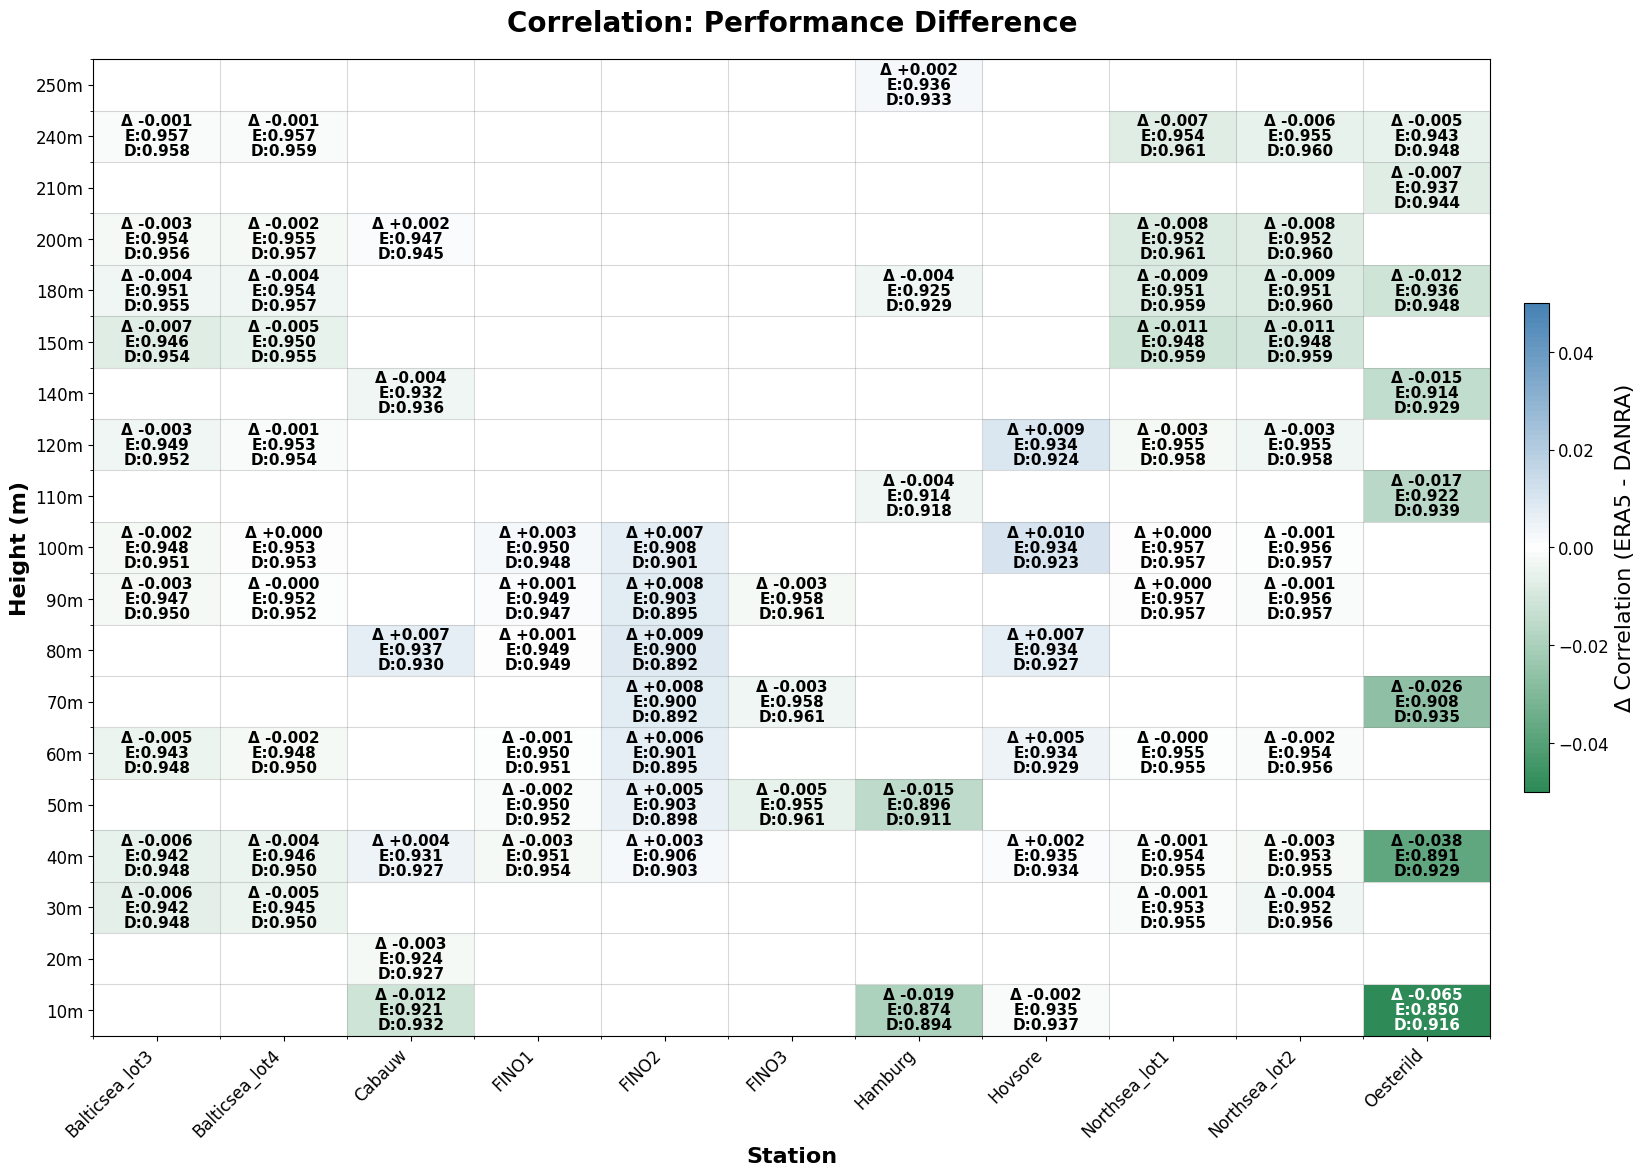

  Saved: Plots\unified_comparison\unified_correlation.png


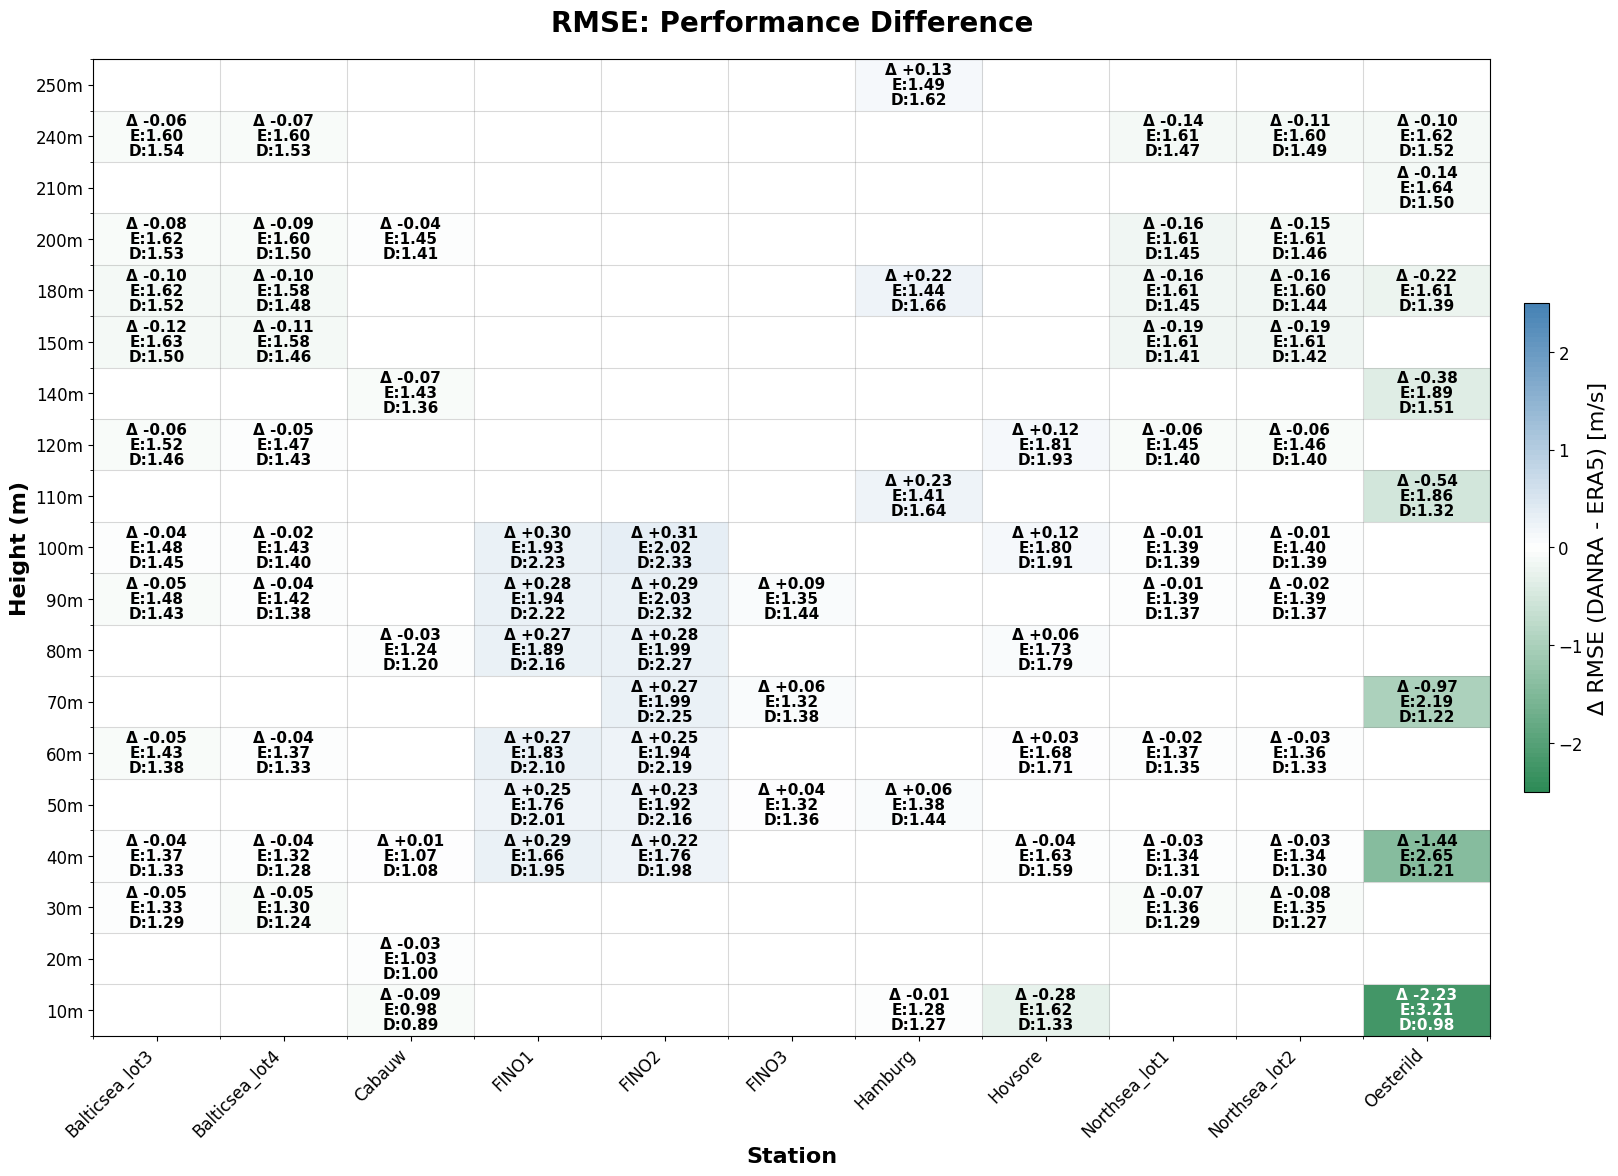

  Saved: Plots\unified_comparison\unified_rmse.png


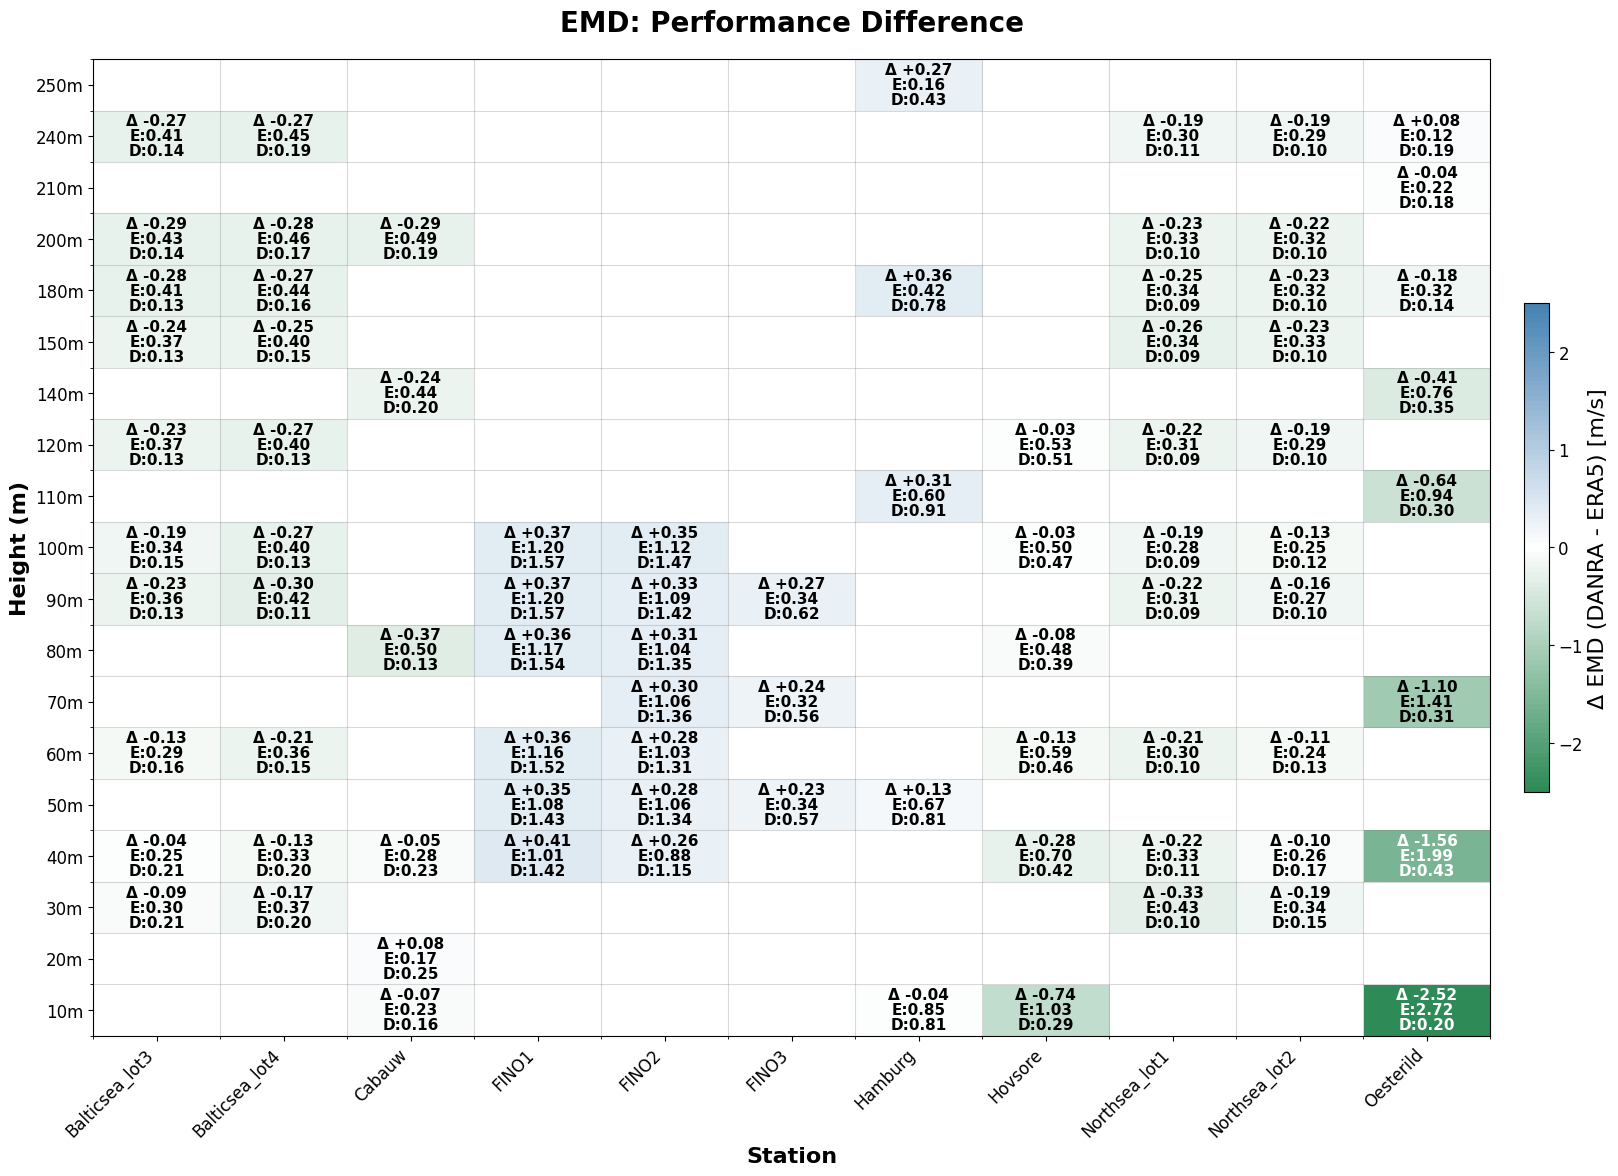

  Saved: Plots\unified_comparison\unified_emd_speed.png


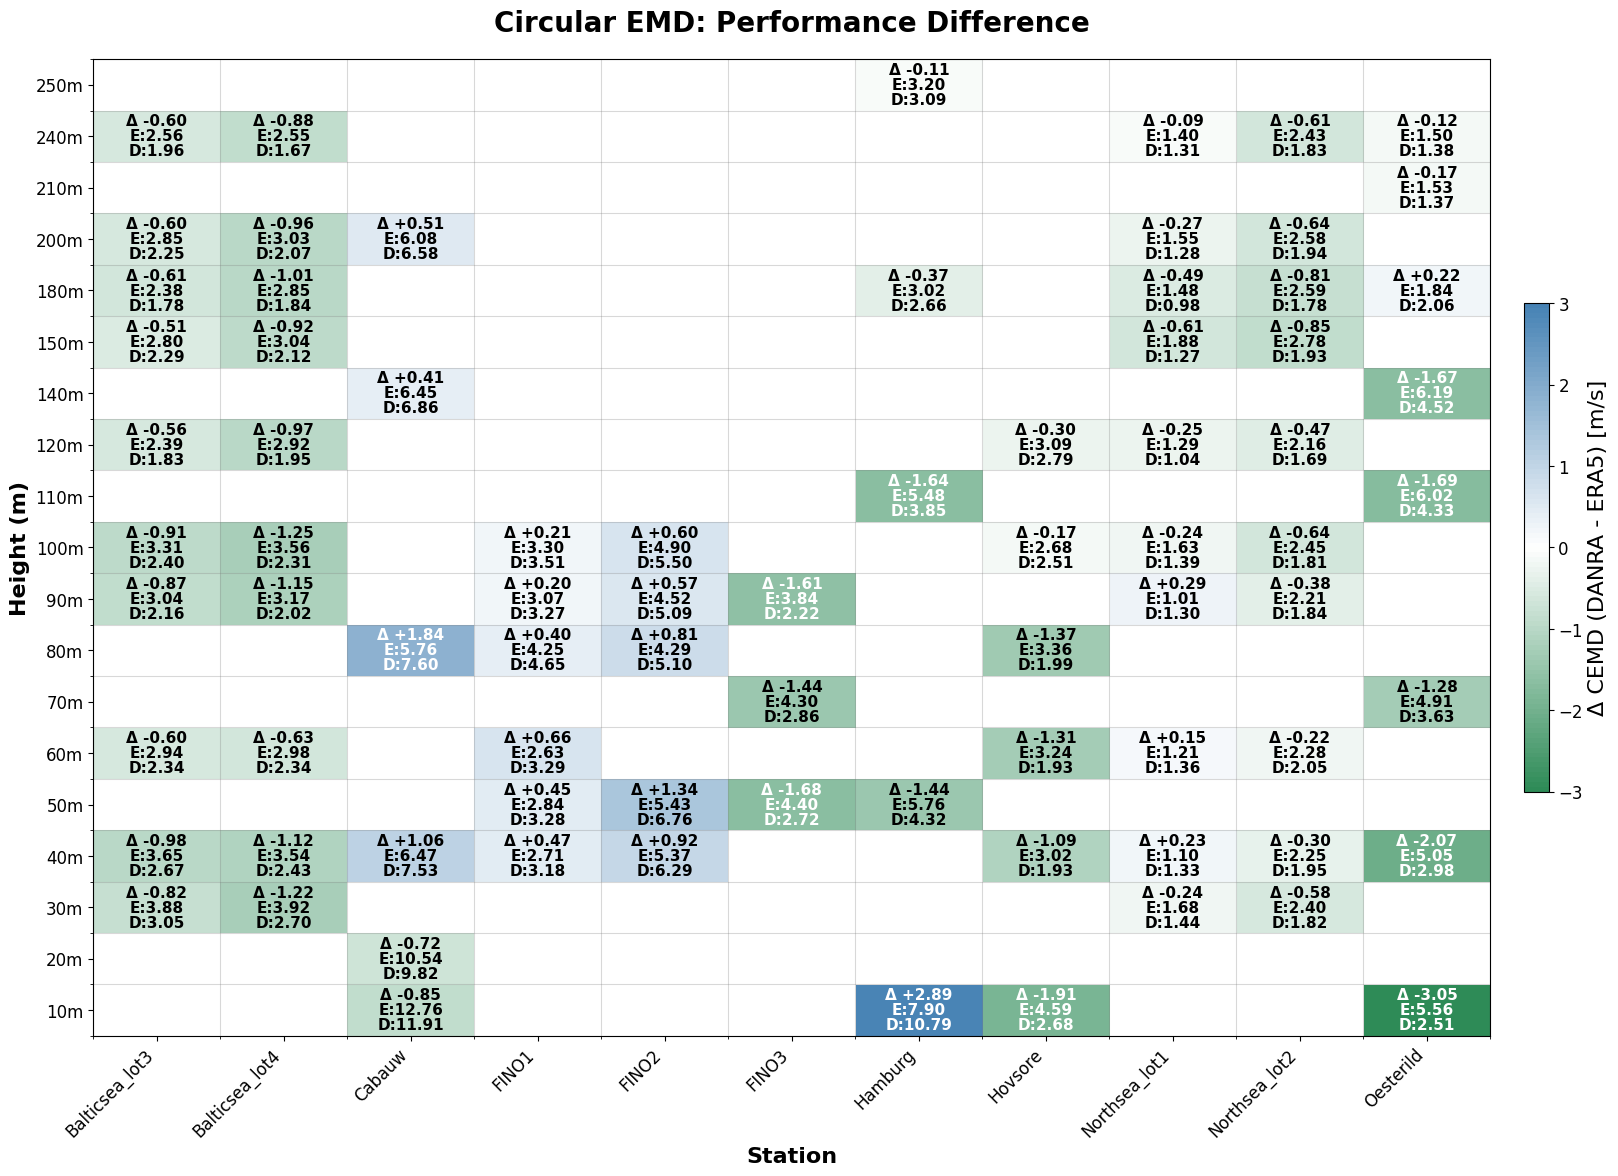

  Saved: Plots\unified_comparison\unified_cemd.png


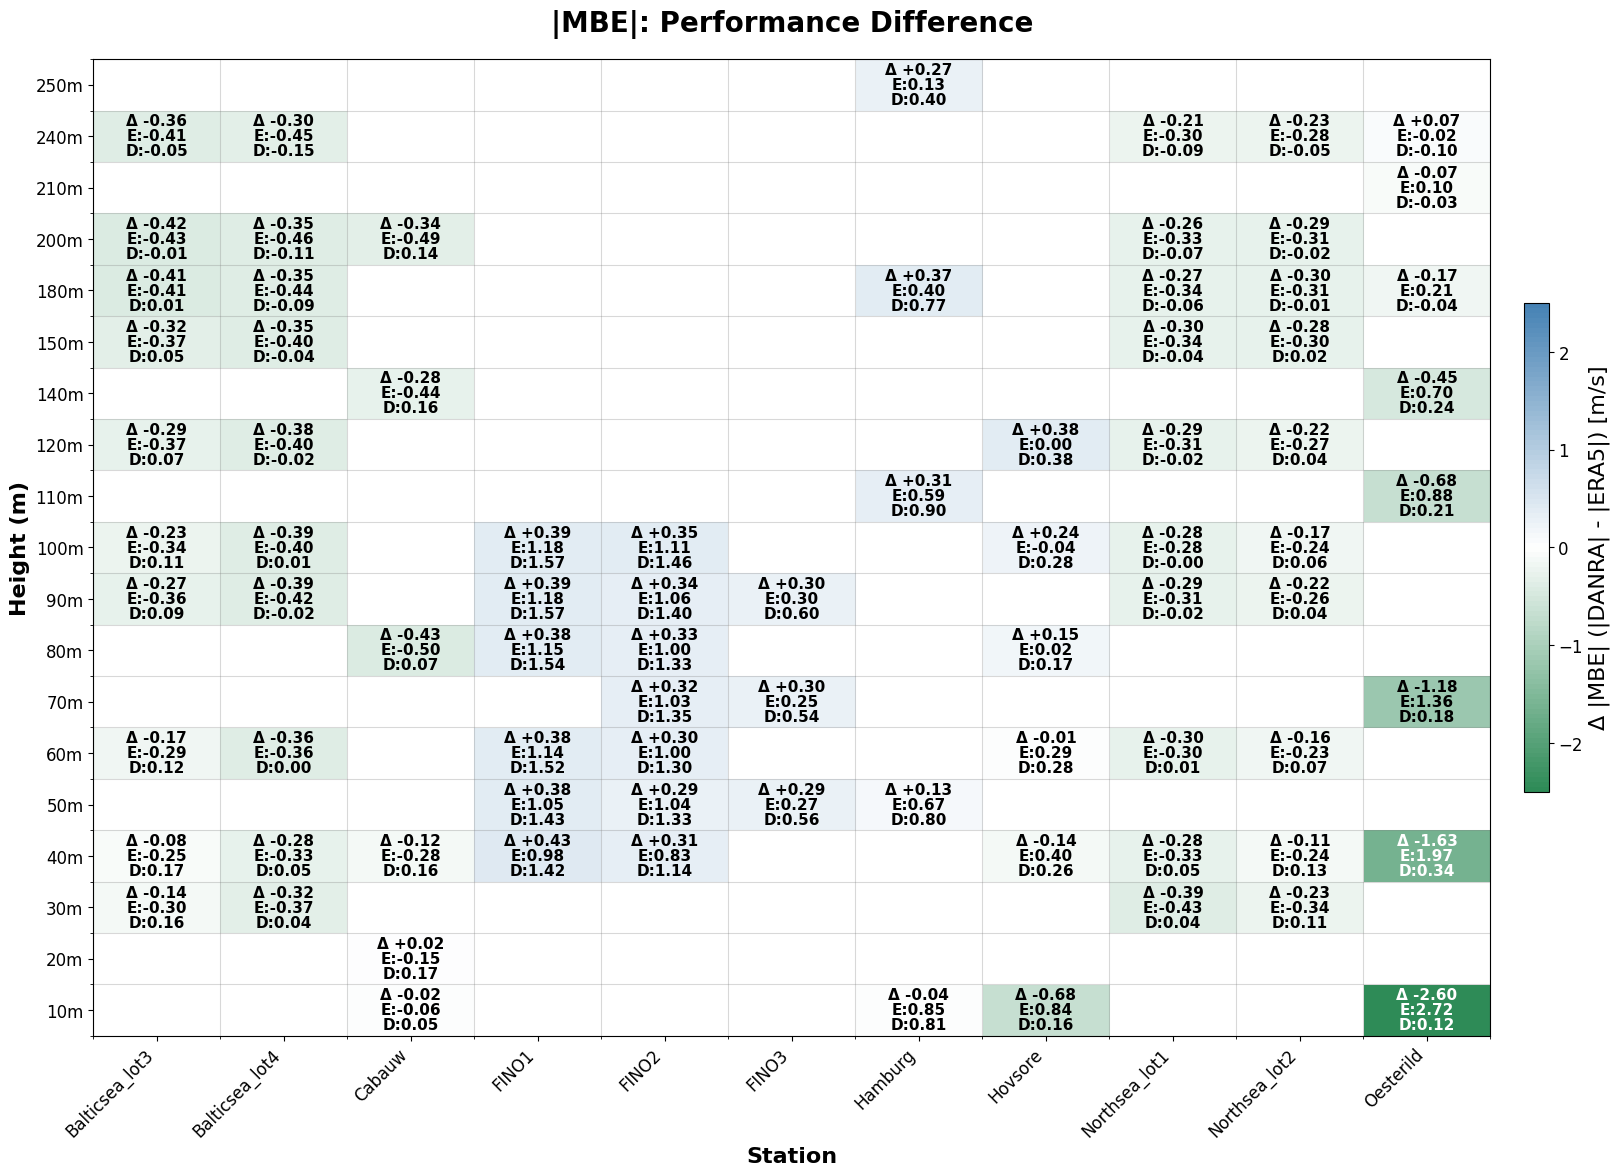

  Saved: Plots\unified_comparison\unified_mbe.png

PERFORMANCE SUMMARY
Metric               ERA5 Better          DANRA Better         Ties            Total          
------------------------------------------------------------------------------------------
Correlation          59                   22                   0               81             
RMSE                 25                   56                   0               81             
EMD                  22                   59                   0               81             
Circular EMD         20                   59                   0               79             
|MBE|                25                   56                   0               81             


In [11]:
def create_unified_performance_heatmap(era5_metrics, danra_metrics, all_stations, 
                                        stations_with_era5, stations_with_danra, 
                                        BIN_CENTRES, output_dir='./Plots', 
                                        remove_empty_bins=True):
    
    output_path = Path(output_dir) / 'unified_comparison'
    output_path.mkdir(parents=True, exist_ok=True)
    
    # Find common stations
    common_stations = sorted(set(stations_with_era5) & set(stations_with_danra))
    
    if not common_stations:
        print("No common stations between ERA5 and DANRA for comparison")
        return
    
    print(f"\n{'='*60}")
    print(f"CREATING UNIFIED PERFORMANCE HEATMAPS")
    print(f"{'='*60}")
    print(f"Comparing {len(common_stations)} common stations: {common_stations}")
    
    # Get station indices
    station_to_idx = {station: idx for idx, station in enumerate(all_stations)}
    common_indices = [station_to_idx[s] for s in common_stations]
    
    # Remove empty height bins if requested
    if remove_empty_bins:
        # Identify which height bins have any data
        valid_height_mask = []
        for i, height in enumerate(BIN_CENTRES):
            has_data = False
            for j in common_indices:
                # Check one metric (rmse) for data presence
                e_val = era5_metrics['rmse'][i, j]
                d_val = danra_metrics['rmse'][i, j]
                if not np.isnan(e_val) and not np.isnan(d_val):
                    has_data = True
                    break
            valid_height_mask.append(has_data)
        
        valid_height_indices = [i for i, valid in enumerate(valid_height_mask) if valid]
        n_heights = len(valid_height_indices)
        used_height_centres = [BIN_CENTRES[i] for i in valid_height_indices]
        height_indices_to_use = valid_height_indices
        
        print(f"Removed {len(BIN_CENTRES) - n_heights} empty height bins")
        print(f"Using {n_heights} height bins: {used_height_centres}")
    else:
        n_heights = len(BIN_CENTRES)
        height_indices_to_use = list(range(n_heights))
        used_height_centres = BIN_CENTRES
    
    # Define metrics with increased font sizes
    metrics_config = {
        'correlation': {
            'name': 'Correlation',
            'unit': '',
            'higher_better': True,
            'cmap': 'RdBu_r',
            'vmin': -0.05,
            'vmax': 0.05,
            'diff_label': 'Δ Correlation (ERA5 - DANRA)',
            'format': '{:.2f}',
            'fontsize': 11  # Increased from 8
        },
        'rmse': {
            'name': 'RMSE',
            'unit': 'm/s',
            'higher_better': False,
            'cmap': 'RdYlGn',
            'vmin': -2.5,
            'vmax': 2.5,
            'diff_label': 'Δ RMSE (DANRA - ERA5) [m/s]',
            'format': '{:+.2f}',
            'fontsize': 11  # Increased from 9
        },
        'emd_speed': {
            'name': 'EMD',
            'unit': 'm/s',
            'higher_better': False,
            'cmap': 'RdYlGn',
            'vmin': -2.5,
            'vmax': 2.5,
            'diff_label': 'Δ EMD (DANRA - ERA5) [m/s]',
            'format': '{:+.2f}',
            'fontsize': 11  # Increased from 9
        },
        'cemd': {
            'name': 'Circular EMD',
            'unit': 'm/s',
            'higher_better': False,
            'cmap': 'RdYlGn',
            'vmin': -3,
            'vmax': 3,
            'diff_label': 'Δ CEMD (DANRA - ERA5) [m/s]',
            'format': '{:+.2f}',
            'fontsize': 11  # Increased from 9
        },
        'mbe': {
            'name': '|MBE|',
            'unit': 'm/s',
            'higher_better': False,
            'cmap': 'RdYlGn',
            'vmin': -2.5,
            'vmax': 2.5,
            'diff_label': 'Δ |MBE| (|DANRA| - |ERA5|) [m/s]',
            'format': '{:+.2f}',
            'fontsize': 11  # Increased from 9
        }
    }
     
    # Create individual heatmaps for each metric
    for metric, config in metrics_config.items():

        cell_width = 1.5  # Inches per station cell
        cell_height = 0.6  # Inches per height cell
        
        fig_width = max(14, len(common_stations) * cell_width + 2)  # +2 for margins
        fig_height = max(8, n_heights * cell_height + 1)  # +2 for margins
        
        fig, ax = plt.subplots(figsize=(fig_width, fig_height))
        
        # Recalculate difference matrix using only the valid heights
        diff_matrix = np.full((n_heights, len(common_stations)), np.nan)
        
        for i, orig_idx in enumerate(height_indices_to_use):
            for j, station in enumerate(common_stations):
                s_idx = station_to_idx[station]
                e_val = era5_metrics[metric][orig_idx, s_idx]
                d_val = danra_metrics[metric][orig_idx, s_idx]
                
                if not np.isnan(e_val) and not np.isnan(d_val):
                    if metric == 'correlation':
                        diff = e_val - d_val
                    elif metric == 'mbe':
                        diff = abs(d_val) - abs(e_val)
                    else:
                        diff = d_val - e_val
                    
                    diff_matrix[i, j] = diff
        
        # Create colormap
        colors = ['#2E8B57', '#FFFFFF', '#4682B4']  # Green, White, Blue
        vmin, vmax = config['vmin'], config['vmax']
        
        custom_cmap = LinearSegmentedColormap.from_list(f'custom_{metric}', colors, N=100)
        
        masked_diff = np.ma.masked_where(np.isnan(diff_matrix), diff_matrix)
        
        im = ax.imshow(masked_diff, cmap=custom_cmap, aspect='auto', 
                      vmin=vmin, vmax=vmax, origin='lower',
                      interpolation='none', rasterized=True)
        
        # Set ticks with increased font sizes
        ax.set_xticks(range(len(common_stations)))
        ax.set_xticklabels(common_stations, rotation=45, ha='right', fontsize=12)  # Increased from 10
        ax.set_yticks(range(n_heights))
        ax.set_yticklabels([f'{h:.0f}m' for h in used_height_centres], fontsize=12)  # Increased from 10
        
        # Add grid with slightly thicker lines
        ax.set_xticks(np.arange(-0.5, len(common_stations), 1), minor=True)
        ax.set_yticks(np.arange(-0.5, n_heights, 1), minor=True)
        ax.grid(which='minor', color='gray', linestyle='-', linewidth=0.8, alpha=0.3)  # Increased linewidth
        ax.grid(False)
        
        # Add annotations with larger font sizes
        for i in range(diff_matrix.shape[0]):
            for j in range(diff_matrix.shape[1]):
                diff_val = diff_matrix[i, j]
                if not np.isnan(diff_val):
                    s_idx = common_indices[j]
                    orig_idx = height_indices_to_use[i]
                    e_val = era5_metrics[metric][orig_idx, s_idx]
                    d_val = danra_metrics[metric][orig_idx, s_idx]
                    
                    # Format text with appropriate decimals
                    if metric == 'correlation':
                        text = f'Δ {diff_val:+.3f}\nE:{e_val:.3f}\nD:{d_val:.3f}'
                    else:
                        text = f'Δ {diff_val:+.2f}\nE:{e_val:.2f}\nD:{d_val:.2f}'
                    
                    fontsize = config.get('fontsize', 10)
                    
                    # Determine text color
                    if metric == 'correlation':
                        if abs(diff_val) > 0.04:  
                            text_color = 'white'
                        else:  
                            text_color = 'black'
                    else:
                        if abs(diff_val) > 1.5:
                            text_color = 'white'
                        else:
                            text_color = 'black'
                    
                    ax.text(j, i, text, ha='center', va='center', 
                           fontsize=fontsize, color=text_color, fontweight='bold',
                           linespacing=1.0)
        
        # Colorbar with larger font
        cbar = plt.colorbar(im, ax=ax, shrink=0.5, pad=0.02)
        cbar.set_label(config['diff_label'], fontsize=16)  # Increased from 12
        cbar.ax.tick_params(labelsize=12)  # Added tick label size
     
        
        # Title and labels with increased font sizes
        ax.set_title(f'{config["name"]}: Performance Difference',
                    # 'E = ERA5 (blue) | D = DANRA (green)',
                    fontsize=20, fontweight='bold', pad=20)  # Increased from 14
        ax.set_xlabel('Station', fontsize=16, fontweight='bold')  # Increased from 12
        ax.set_ylabel('Height (m)', fontsize=16, fontweight='bold')  # Increased from 12

        plt.subplots_adjust(top=0.95) 
        plt.tight_layout(pad=3.0)  # Increased padding
        plt.savefig(output_path / f'unified_{metric}.png', dpi=200, bbox_inches='tight')
        plt.show()
        plt.close()
        
        print(f"  Saved: {output_path / f'unified_{metric}.png'}")
    
    # Create summary statistics table with better formatting
    print(f"\n{'='*60}")
    print("PERFORMANCE SUMMARY")
    print(f"{'='*60}")
    print(f"{'Metric':<20} {'ERA5 Better':<20} {'DANRA Better':<20} {'Ties':<15} {'Total':<15}")
    print(f"{'-'*90}")
    
    for metric, config in metrics_config.items():
        era5_better = 0
        danra_better = 0
        ties = 0
        
        for i in range(n_heights):
            orig_idx = height_indices_to_use[i]
            for j in common_indices:
                e_val = era5_metrics[metric][orig_idx, j]
                d_val = danra_metrics[metric][orig_idx, j]
                
                if not np.isnan(e_val) and not np.isnan(d_val):
                    if metric == 'correlation':
                        if e_val < d_val:
                            era5_better += 1
                        elif d_val < e_val:
                            danra_better += 1
                        else:
                            ties += 1
                    elif metric == 'mbe':
                        if abs(e_val) < abs(d_val):
                            era5_better += 1
                        elif abs(d_val) < abs(e_val):
                            danra_better += 1
                        else:
                            ties += 1
                    else:
                        if e_val < d_val:
                            era5_better += 1
                        elif d_val < e_val:
                            danra_better += 1
                        else:
                            ties += 1
        
        total = era5_better + danra_better + ties
        print(f"{config['name']:<20} {era5_better:<20} {danra_better:<20} {ties:<15} {total:<15}")
    
    return True

# Generate unified performance heatmaps
print("\n" + "="*80)
print("GENERATING UNIFIED PERFORMANCE HEATMAPS")
print("="*80)

unified_result = create_unified_performance_heatmap(
    era5_metrics, 
    danra_metrics, 
    all_stations, 
    stations_with_era5, 
    stations_with_danra, 
    BIN_CENTRES,
    output_dir='./Plots'
)

In [12]:
import matplotlib.pyplot as plt
import numpy as np
from pathlib import Path
from matplotlib.patches import Patch
import random

# ============================================================
# SETUP AND DATA PREPARATION
# ============================================================

output_path = Path('./Plots/boxplots_stations')
output_path.mkdir(parents=True, exist_ok=True)

# Find common stations
common_stations = sorted(set(stations_with_era5) & set(stations_with_danra))

if not common_stations:
    print("No common stations between ERA5 and DANRA for box plots")
    exit()

print(f"\n{'='*60}")
print(f"CREATING STATION-BASED BOXPLOTS WITH HEIGHT VARIABILITY TRACKING")
print(f"{'='*60}")
print(f"Comparing {len(common_stations)} common stations: {common_stations}")

# Get station indices
station_to_idx = {station: idx for idx, station in enumerate(all_stations)}
common_indices = [station_to_idx[s] for s in common_stations]

# Find which height bins actually have data
valid_height_indices = []
for i, height in enumerate(BIN_CENTRES):
    has_data = False
    for j in common_indices:
        if not np.isnan(era5_metrics['rmse'][i, j]) or not np.isnan(danra_metrics['rmse'][i, j]):
            has_data = True
            break
    if has_data:
        valid_height_indices.append(i)

if not valid_height_indices:
    print("No valid height bins found")
    exit()

heights = [BIN_CENTRES[i] for i in valid_height_indices]
n_heights = len(heights)
n_stations = len(common_stations)
x_positions = np.arange(n_stations)
width = 0.35

# Metrics configuration
metrics_config = {
    'correlation': {
        'name': 'Correlation',
        'ylabel': 'Correlation Coefficient',
        'higher_better': True,
        'perfect_value': 1.0,
        'diff_label': 'Δ Correlation (ERA5 - DANRA)',
        'better_explanation': 'Positive = ERA5 Better, Negative = DANRA Better',
        'filename': 'correlation'
    },
    'rmse': {
        'name': 'RMSE',
        'ylabel': 'RMSE (m/s)',
        'higher_better': False,
        'perfect_value': 0.0,
        'diff_label': 'Δ RMSE (ERA5 - DANRA)',
        'better_explanation': 'Positive = ERA5 Better, Negative = DANRA Better',
        'filename': 'rmse'
    },
    'emd_speed': {
        'name': 'EMD',
        'ylabel': 'EMD (m/s)',
        'higher_better': False,
        'perfect_value': 0.0,
        'diff_label': 'Δ EMD (ERA5 - DANRA)',
        'better_explanation': 'Positive = ERA5 Better, Negative = DANRA Better',
        'filename': 'emd_speed'
    },
    'cemd': {
        'name': 'cEMD',
        'ylabel': 'cEMD (m/s)',
        'higher_better': False,
        'perfect_value': 0.0,
        'diff_label': 'Δ CEMD (ERA5 - DANRA)',
        'better_explanation': 'Positive = ERA5 Better, Negative = DANRA Better',
        'filename': 'cemd'
    },
    'mbe': {
        'name': 'MBE',
        'ylabel': 'MBE (m/s)',
        'higher_better': False,
        'perfect_value': 0.0,
        'diff_label': 'Δ |MBE| (|ERA5| - |DANRA|)',
        'better_explanation': 'Positive = ERA5 Better, Negative = DANRA Better',
        'filename': 'mbe'
    },
    'n_hours': {
        'name': 'Data Availability',
        'ylabel': 'Number of Hours',
        'higher_better': True,
        'perfect_value': None,
        'diff_label': 'Δ Hours (DANRA - ERA5)',
        'better_explanation': 'Positive = ERA5 Better, Negative = DANRA Better',
        'filename': 'n_hours'
    }
}

# ============================================================
# Generate plots for each metric
# ============================================================
print("\nGenerating plots...")

for metric_key, config in metrics_config.items():
    
    # Collect data for each station (across heights)
    era5_data_by_station = []
    danra_data_by_station = []
    
    for station in common_stations:
        s_idx = station_to_idx[station]
        era5_vals = []
        danra_vals = []
        
        for height_idx in valid_height_indices:
            e_val = era5_metrics[metric_key][height_idx, s_idx]
            d_val = danra_metrics[metric_key][height_idx, s_idx]
            
            if not np.isnan(e_val):
                era5_vals.append(e_val)
            else:
                era5_vals.append(np.nan)
                
            if not np.isnan(d_val):
                danra_vals.append(d_val)
            else:
                danra_vals.append(np.nan)
        
        era5_data_by_station.append(era5_vals if era5_vals else [np.nan])
        danra_data_by_station.append(danra_vals if danra_vals else [np.nan])
    
    # # ============================================================
    # # PLOT 1: Box plots with individual station points
    # # ============================================================
    # fig1, ax1 = plt.subplots(figsize=(14, 8))
    
    # # Add reference line for perfect score if needed
    # if config['perfect_value'] is not None:
    #     ax1.axhline(y=config['perfect_value'], color='red', linestyle='--', 
    #                linewidth=2, alpha=0.7, label='Perfect')
    
    # # ERA5 box plots
    # bp1 = ax1.boxplot(era5_data_by_station, positions=x_positions - width/2, 
    #                  widths=width, patch_artist=True,
    #                  boxprops=dict(facecolor='#4682B4', alpha=0.7),
    #                  medianprops=dict(color='darkblue', linewidth=2),
    #                  whiskerprops=dict(color='darkblue', linestyle='--'),
    #                  capprops=dict(color='darkblue'),
    #                  flierprops=dict(marker='o', markerfacecolor='blue', 
    #                                 markersize=4, alpha=0.5))
    
    # # DANRA box plots
    # bp2 = ax1.boxplot(danra_data_by_station, positions=x_positions + width/2, 
    #                  widths=width, patch_artist=True,
    #                  boxprops=dict(facecolor='#2E8B57', alpha=0.7),
    #                  medianprops=dict(color='darkgreen', linewidth=2),
    #                  whiskerprops=dict(color='darkgreen', linestyle='--'),
    #                  capprops=dict(color='darkgreen'),
    #                  flierprops=dict(marker='o', markerfacecolor='green', 
    #                                 markersize=4, alpha=0.5))
    
    # # Add individual station points
    # for i, (era5_vals, danra_vals) in enumerate(zip(era5_data_by_station, danra_data_by_station)):
    #     # ERA5 points
    #     valid_era5 = [v for v in era5_vals if not np.isnan(v)]
    #     if valid_era5:
    #         x_jitter = np.random.normal(0, 0.02, len(valid_era5))
    #         ax1.scatter([x_positions[i] - width/2 + x_jitter[k] for k in range(len(valid_era5))], 
    #                    valid_era5, alpha=0.3, s=20, color='blue', 
    #                    edgecolors='none', linewidth=0)
        
    #     # DANRA points
    #     valid_danra = [v for v in danra_vals if not np.isnan(v)]
    #     if valid_danra:
    #         x_jitter = np.random.normal(0, 0.02, len(valid_danra))
    #         ax1.scatter([x_positions[i] + width/2 + x_jitter[k] for k in range(len(valid_danra))], 
    #                    valid_danra, alpha=0.3, s=20, color='green',
    #                    edgecolors='none', linewidth=0)
    
    # ax1.set_xticks(x_positions)
    # ax1.set_xticklabels(common_stations, rotation=45, ha='right', fontsize=9)
    # ax1.set_xlabel('Station', fontsize=14)
    # ax1.set_ylabel(config['ylabel'], fontsize=14)
    # ax1.set_title(f'{config["name"]} by Station\n(Points show individual heights)', 
    #              fontsize=16, fontweight='bold')
    
    # legend_elements = [
    #     plt.Line2D([0], [0], color='blue', linewidth=2, label='ERA5'),
    #     plt.Line2D([0], [0], color='green', linewidth=2, label='DANRA'),
    # ]
    # if config['perfect_value'] is not None:
    #     legend_elements.append(plt.Line2D([0], [0], color='red', linestyle='--', linewidth=2, label='Perfect'))
    
    # ax1.legend(handles=legend_elements, loc='best', fontsize=11)
    # ax1.grid(True, alpha=0.3, linestyle='--')
    
    # # Add sample size info
    # n_era5_total = sum(len([v for v in vals if not np.isnan(v)]) for vals in era5_data_by_station)
    # n_danra_total = sum(len([v for v in vals if not np.isnan(v)]) for vals in danra_data_by_station)
    # ax1.text(0.02, 0.98, f'Total samples: ERA5={n_era5_total}, DANRA={n_danra_total}', 
    #         transform=ax1.transAxes, fontsize=10, verticalalignment='top',
    #         bbox=dict(boxstyle='round', facecolor='white', alpha=0.8))
    
    # plt.tight_layout()
    # plt.savefig(output_path / f'{config["filename"]}_station_boxplot.png', dpi=200, bbox_inches='tight')
    # plt.close()
    # print(f"  Saved: {output_path / f'{config["filename"]}_station_boxplot.png'}")
    
    # # ============================================================
    # # PLOT 2: Height tracking lines per station
    # # ============================================================
    # fig2, ax2 = plt.subplots(figsize=(16, 8))
    
    # n_heights_to_show = min(5, len(heights))
    # selected_heights = heights[:n_heights_to_show]
    # colors = plt.cm.tab10(np.linspace(0, 1, n_heights_to_show))
    
    # handles = []
    # labels = []
    
    # # Plot height tracking for ERA5
    # for idx, height in enumerate(selected_heights):
    #     height_idx = valid_height_indices[heights.index(height)]
    #     height_vals = []
    #     station_indices = []
        
    #     for j, station in enumerate(common_stations):
    #         s_idx = station_to_idx[station]
    #         val = era5_metrics[metric_key][height_idx, s_idx]
    #         if not np.isnan(val):
    #             height_vals.append(val)
    #             station_indices.append(j)
        
    #     if height_vals:
    #         line, = ax2.plot(station_indices, height_vals, 
    #                         'o-', color=colors[idx], alpha=0.7, 
    #                         markersize=6, linewidth=1.5)
    #         handles.append(line)
    #         labels.append(f'{height:.0f}m (ERA5)')
    
    # # Plot height tracking for DANRA
    # for idx, height in enumerate(selected_heights):
    #     height_idx = valid_height_indices[heights.index(height)]
    #     height_vals = []
    #     station_indices = []
        
    #     for j, station in enumerate(common_stations):
    #         s_idx = station_to_idx[station]
    #         val = danra_metrics[metric_key][height_idx, s_idx]
    #         if not np.isnan(val):
    #             height_vals.append(val)
    #             station_indices.append(j)
        
    #     if height_vals:
    #         line, = ax2.plot(station_indices, height_vals, 
    #                         's--', color=colors[idx], alpha=0.5, 
    #                         markersize=5, linewidth=1.5)
    #         handles.append(line)
    #         labels.append(f'{height:.0f}m (DANRA)')
    
    # ax2.set_xticks(x_positions)
    # ax2.set_xticklabels(common_stations, rotation=45, ha='right', fontsize=14)
    # ax2.set_xlabel('Station', fontsize=14)
    # ax2.set_ylabel(config['ylabel'], fontsize=14)
    # ax2.set_title(f'{config["name"]} - Height Performance Tracking Across Stations', 
    #              fontsize=16, fontweight='bold')
    
    # if handles:
    #     ax2.legend(handles, labels, loc='best', fontsize=12, ncol=2)
    
    # ax2.grid(True, alpha=0.3, linestyle='--')
    
    # if len(heights) > n_heights_to_show:
    #     ax2.text(0.02, 0.02, f'Showing {n_heights_to_show} of {len(heights)} heights', 
    #             transform=ax2.transAxes, fontsize=10, verticalalignment='bottom',
    #             bbox=dict(boxstyle='round', facecolor='white', alpha=0.8))
    
    # plt.tight_layout()
    # plt.savefig(output_path / f'{config["filename"]}_height_tracking.png', dpi=200, bbox_inches='tight')
    # plt.close()
    # print(f"  Saved: {output_path / f'{config["filename"]}_height_tracking.png'}")
    
    # ============================================================
    # PLOT 3: Difference between ERA5 and DANRA per station
    # ============================================================
    fig3, ax3 = plt.subplots(figsize=(12, 7))
    
    diff_data_by_station = []
    
    for station in common_stations:
        s_idx = station_to_idx[station]
        diff_vals = []
        
        for height_idx in valid_height_indices:
            e_val = era5_metrics[metric_key][height_idx, s_idx]
            d_val = danra_metrics[metric_key][height_idx, s_idx]
            
            if not np.isnan(e_val) and not np.isnan(d_val):
                if metric_key == 'correlation':
                    diff = e_val - d_val
                elif metric_key == 'mbe':
                    diff = abs(d_val) - abs(e_val)
                elif metric_key == 'n_hours':
                    diff = d_val - e_val
                else:
                    diff = d_val - e_val
                
                diff_vals.append(diff)
        
        diff_data_by_station.append(diff_vals if diff_vals else [np.nan])
    
    # Create box plot of differences per station
    bp_diff = ax3.boxplot(diff_data_by_station, positions=x_positions, 
                         widths=0.6, patch_artist=True,
                         boxprops=dict(facecolor='lightgray', alpha=0.7),
                         medianprops=dict(color='black', linewidth=2),
                         whiskerprops=dict(color='black', linestyle='--'),
                         capprops=dict(color='black'))
    
    # Add individual points colored by sign
    for i, diff_vals in enumerate(diff_data_by_station):
        if len(diff_vals) > 0 and not (len(diff_vals) == 1 and np.isnan(diff_vals[0])):
            x_jitter = np.random.normal(0, 0.02, len(diff_vals))
            
            for j, diff_val in enumerate(diff_vals):
                if diff_val < 0:
                    color = '#2E8B57'  # Green - Negative
                elif diff_val > 0:
                    color = '#4682B4'  # Blue - Positive
                else:
                    color = 'gray'
                
                ax3.scatter(x_positions[i] + x_jitter[j], diff_val, 
                           alpha=0.6, s=30, color=color,
                           edgecolors='white', linewidth=0.5)
    
    ax3.axhline(y=0, color='black', linestyle='-', linewidth=2, alpha=0.7)
    
    ax3.set_xticks(x_positions)
    ax3.set_xticklabels(common_stations, rotation=45, ha='right', fontsize=12)
    ax3.set_xlabel('Station', fontsize=14, fontweight='bold')
    ax3.set_ylabel(config['diff_label'], fontsize=14, fontweight='bold')
    ax3.set_title(f'{config["name"]}: Difference in Reanalysis by Station', 
                 fontsize=16 , fontweight='bold', pad=20)
    ax3.grid(True, alpha=0.3, linestyle='--')
    ax3.tick_params(axis='y', labelsize=12)
    
    # # Legend
    # if metric_key == 'correlation':
    #     legend_elements = [
    #         Patch(facecolor='#2E8B57', alpha=0.6, label='Positive (ERA5 Better)'),
    #         Patch(facecolor='#4682B4', alpha=0.6, label='Negative (DANRA Better)'),
    #         Patch(facecolor='gray', alpha=0.6, label='Tie')
    #     ]
    # elif metric_key == 'n_hours':
    #     legend_elements = [
    #         Patch(facecolor='#2E8B57', alpha=0.6, label='Positive (DANRA Better)'),
    #         Patch(facecolor='#4682B4', alpha=0.6, label='Negative (ERA5 Better)'),
    #         Patch(facecolor='gray', alpha=0.6, label='Tie')
    #     ]
    # else:
    #     legend_elements = [
    #         Patch(facecolor='#2E8B57', alpha=0.6, label='Positive (DANRA Better)'),
    #         Patch(facecolor='#4682B4', alpha=0.6, label='Negative (ERA5 Better)'),
    #         Patch(facecolor='gray', alpha=0.6, label='Tie')
    #     ]
    
    # ax3.legend(handles=legend_elements, loc='lower right', fontsize=12)
    plt.subplots_adjust(top=0.8) 
    plt.tight_layout()
    plt.savefig(output_path / f'{config["filename"]}_station_difference.png', dpi=200, bbox_inches='tight')
    plt.close()
    print(f"  Saved: {output_path / f'{config["filename"]}_station_difference.png'}")

# ============================================================
# Summary Statistics
# ============================================================
print("\n" + "="*60)
print("PERFORMANCE SUMMARY BY STATION")
print("="*60)
print(f"{'Station':<12} {'Metric':<12} {'ERA5 Mean':<12} {'DANRA Mean':<12} {'Better':<10}")
print(f"{'-'*60}")

# Helper function to determine which model is better
def get_better_model(e_val, d_val, metric_key):
    if np.isnan(e_val) or np.isnan(d_val):
        return None
    
    if metric_key == 'correlation' or metric_key == 'n_hours':
        if e_val > d_val:
            return 'ERA5'
        elif d_val > e_val:
            return 'DANRA'
        else:
            return 'Tie'
    elif metric_key == 'mbe':
        if abs(e_val) < abs(d_val):
            return 'ERA5'
        elif abs(d_val) < abs(e_val):
            return 'DANRA'
        else:
            return 'Tie'
    else:
        if e_val < d_val:
            return 'ERA5'
        elif d_val < e_val:
            return 'DANRA'
        else:
            return 'Tie'

# Select a few key metrics for summary
summary_metrics = ['correlation', 'rmse', 'mbe']

for station in common_stations:
    s_idx = station_to_idx[station]
    for metric_key in summary_metrics:
        era5_vals = []
        danra_vals = []
        
        for height_idx in valid_height_indices:
            e_val = era5_metrics[metric_key][height_idx, s_idx]
            d_val = danra_metrics[metric_key][height_idx, s_idx]
            if not np.isnan(e_val):
                era5_vals.append(e_val)
            if not np.isnan(d_val):
                danra_vals.append(d_val)
        
        if era5_vals and danra_vals:
            era5_mean = np.mean(era5_vals)
            danra_mean = np.mean(danra_vals)
            better = get_better_model(era5_mean, danra_mean, metric_key)
            
            metric_name = metrics_config[metric_key]['name']
            print(f"{station:<12} {metric_name:<12} {era5_mean:<12.3f} {danra_mean:<12.3f} {better:<10}")

print(f"\nAll plots saved to: {output_path}")


CREATING STATION-BASED BOXPLOTS WITH HEIGHT VARIABILITY TRACKING
Comparing 11 common stations: ['Balticsea_lot3', 'Balticsea_lot4', 'Cabauw', 'FINO1', 'FINO2', 'FINO3', 'Hamburg', 'Hovsore', 'Northsea_lot1', 'Northsea_lot2', 'Oesterild']

Generating plots...
  Saved: Plots\boxplots_stations\correlation_station_difference.png
  Saved: Plots\boxplots_stations\rmse_station_difference.png
  Saved: Plots\boxplots_stations\emd_speed_station_difference.png
  Saved: Plots\boxplots_stations\cemd_station_difference.png
  Saved: Plots\boxplots_stations\mbe_station_difference.png
  Saved: Plots\boxplots_stations\n_hours_station_difference.png

PERFORMANCE SUMMARY BY STATION
Station      Metric       ERA5 Mean    DANRA Mean   Better    
------------------------------------------------------------
Balticsea_lot3 Correlation  0.948        0.952        DANRA     
Balticsea_lot3 RMSE         1.507        1.442        DANRA     
Balticsea_lot3 MBE          -0.353       0.071        DANRA     
Balticsea